# STAI-X 2026 — Unified experiments
**Two-sample testing (§4.1) · online-regression OSGD detection (§4.2) · streaming-MNIST CNN (§5).**

Run Section 0 first, then Restart Kernel → Run All. The Wasserstein spatial-depth core and the shared detection helper are defined once (Section 1) and reused everywhere; only genuinely shared code is merged. Figure and LaTeX-table cells from the source notebooks are omitted.

## Section 0 — Environment, imports and shared constants

In [1]:
# === Environment setup -- run this cell first, then Restart Kernel -> Run All ===
# Fixes the import error: numpy.dtype size changed (Expected 96, got 88).
# This env's compiled packages (h5py, POT's lp solver, ...) were built against
# numpy 1.x, but numpy 2.x is installed, so their C-ABI no longer matches.
# Pinning numpy back to 1.x lines the compiled extensions up again.
# Idempotent: once you're on numpy 1.x it does nothing. Touches only numpy.
import sys, subprocess, importlib.metadata as _md
try:
    _v = _md.version("numpy")
except _md.PackageNotFoundError:
    _v = "0"
if int(_v.split(".")[0]) >= 2:
    subprocess.run([sys.executable, "-m", "pip", "install", "numpy<2"], check=True)
    print("\n>>> numpy pinned to <2. Now RESTART THE KERNEL and Run All. <<<")
else:
    print(f"numpy {_v} -- OK, nothing to do.")

numpy 1.26.4 -- OK, nothing to do.


In [2]:
# Shared imports and constants for all three experiments.
import os, sys, time, csv, copy, math, gc, pickle, warnings
import numpy as np
import pandas as pd
import ot
from collections import deque, Counter
from joblib import Parallel, delayed
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import roc_auc_score, roc_curve
import torch
import torch.nn as nn
import torch.nn.functional as F

warnings.filterwarnings("ignore")
np.set_printoptions(precision=3, suppress=True)
EPS = 1e-12

## Section 1 — Shared core
Defined once and reused by all three experiments.

### 1.1 Wasserstein spatial depth (canonical)
`compute_WSD_X` (leave-one-out reference depths), `compute_WSD_Y` (query-vs-reference), the `(M, n, d, 2)` packers, and the empirical p-value `wsd_what` ($\widehat w_t=\mathrm{mean}(\text{ref depths}\le\text{batch depth})$). Exact `ot.emd`, $W_2$-normalised. Default `n_jobs=-1`; CNN passes `n_jobs=1` and regression passes `WSD_NJOBS`, so per-experiment behaviour is unchanged.

In [3]:
def compute_WSD_X(X, labels, n_jobs=-1):
    """
    Wasserstein spatial depth of each distribution in X with respect
    to its own cluster.
    """
    if X.ndim != 4 or X.shape[-1] != 2:
        raise ValueError("X must be (M, n, d, 2)")
    M, n, d, _ = X.shape
    coords  = X[..., 0].astype(np.float64, copy=False)
    weights = X[:, :, 0, 1].astype(np.float64, copy=False)
    s = weights.sum(axis=1, keepdims=True); s[s <= 0] = 1.0
    weights = weights / s

    def _wsd_i(i):
        wi = np.ascontiguousarray(weights[i], dtype=np.float64)
        Xi = np.ascontiguousarray(coords[i],  dtype=np.float64)
        members = np.where(labels == labels[i])[0]
        members = members[members != i]
        if members.size == 0:
            return 1.0
        m_acc = np.zeros((n, d), dtype=np.float64)
        for j in members:
            wj = np.ascontiguousarray(weights[j], dtype=np.float64)
            Xj = np.ascontiguousarray(coords[j],  dtype=np.float64)
            C  = np.ascontiguousarray(ot.dist(Xi, Xj, metric="euclidean")**2, dtype=np.float64)
            Pi = ot.emd(wi, wj, C)
            T_vals = (Pi @ Xj) / (wi[:, None] + EPS)
            W2 = np.sqrt((Pi * C).sum()) + EPS
            m_acc += (Xi - T_vals) / W2
        m_vec = m_acc / members.size
        norm_sq = np.sum(m_vec**2, axis=1)
        return 1.0 - np.sqrt(np.sum(wi * norm_sq))

    depths = Parallel(n_jobs=n_jobs)(delayed(_wsd_i)(i) for i in range(M))
    return np.array(depths)


def compute_WSD_Y(Y, X, n_jobs=1):
    """
    Wasserstein spatial depth of Y with respect to a reference set X.
    """
    if Y.ndim != 4 or X.ndim != 4 or Y.shape[-1] != 2 or X.shape[-1] != 2:
        raise ValueError("Y/X must be (M, n, d, 2)")
    if (Y.shape[1], Y.shape[2]) != (X.shape[1], X.shape[2]):
        raise ValueError("Y and X must share the same (n, d) for EMD pairing.")
    My, n, d, _ = Y.shape
    Mx = X.shape[0]
    coordsY  = Y[..., 0].astype(np.float64, copy=False)
    coordsX  = X[..., 0].astype(np.float64, copy=False)
    weightsY = Y[:, :, 0, 1].astype(np.float64, copy=False)
    weightsX = X[:, :, 0, 1].astype(np.float64, copy=False)
    sY = weightsY.sum(axis=1, keepdims=True); sY[sY <= 0] = 1.0
    sX = weightsX.sum(axis=1, keepdims=True); sX[sX <= 0] = 1.0
    weightsY = weightsY / sY
    weightsX = weightsX / sX

    def _wsd_y(m):
        wy = np.ascontiguousarray(weightsY[m], dtype=np.float64)
        Yp = np.ascontiguousarray(coordsY[m],  dtype=np.float64)
        if Mx == 0:
            return 1.0
        m_acc = np.zeros((n, d), dtype=np.float64)
        for k in range(Mx):
            wk = np.ascontiguousarray(weightsX[k], dtype=np.float64)
            Xp = np.ascontiguousarray(coordsX[k],  dtype=np.float64)
            C  = np.ascontiguousarray(ot.dist(Yp, Xp, metric="euclidean")**2, dtype=np.float64)
            Pi = ot.emd(wy, wk, C)
            T_vals = (Pi @ Xp) / (wy[:, None] + EPS)
            W2 = np.sqrt((Pi * C).sum()) + EPS
            m_acc += (Yp - T_vals) / W2
        m_vec = m_acc / Mx
        norm_sq = np.sum(m_vec**2, axis=1)
        return 1.0 - np.sqrt(np.sum(wy * norm_sq))

    depths = Parallel(n_jobs=n_jobs)(delayed(_wsd_y)(m) for m in range(My))
    return np.array(depths)


def bags_to_wsd_array(bags):
    """1D bags (M, m) -> (M, m, 1, 2) with uniform weights."""
    bags = np.asarray(bags, dtype=np.float64)
    if bags.ndim != 2:
        raise ValueError("bags must have shape (M, m).")
    M, m = bags.shape
    X = np.zeros((M, m, 1, 2), dtype=np.float64)
    X[:, :, 0, 0] = bags
    X[:, :, 0, 1] = 1.0 / m
    return X


def bags_to_wsd_array_2d(bags):
    """2D bags (M, m, d) -> (M, m, d, 2) with uniform weights."""
    bags = np.asarray(bags, dtype=np.float64)
    M, m, d = bags.shape
    X = np.zeros((M, m, d, 2), dtype=np.float64)
    X[..., 0] = bags
    X[:, :, 0, 1] = 1.0 / m
    return X


def wsd_what(stream_bags, Xw_ref, depths_ref, dim, n_jobs=-1):
    """Per-batch WSD empirical p-value w_hat = mean(depths_ref <= batch_depth).
    dim=1 -> 1D bags (M,m); dim=2 -> 2D bags (M,m,d). Returns (w_hat[], depth[])."""
    if dim == 1:
        Yw = bags_to_wsd_array(stream_bags)
    else:
        Yw = bags_to_wsd_array_2d(stream_bags)
    dS = compute_WSD_Y(Yw, Xw_ref, n_jobs=n_jobs)
    what = np.array([float(np.mean(depths_ref <= d)) for d in dS])
    return what, dS


### 1.2 Shared detection helper
`alpha_table` — per-$\alpha$ FPR / TPR / precision under the flag rule $\widehat w_t<\alpha$ (used by both the regression and CNN evaluators).

In [4]:
def alpha_table(rstat, anom, alphas, mask=None):
    """FPR / TPR / precision per alpha; flag batch t when its p-value < alpha
    (Algorithm 1 rule). Shared by the regression and CNN detectors."""
    r = np.asarray(rstat, dtype=float)
    t = np.asarray(anom).astype(bool)
    m = (~np.isnan(r)) if mask is None else (np.asarray(mask, bool) & ~np.isnan(r))
    r, t = r[m], t[m]
    n_norm, n_anom = int((~t).sum()), int(t.sum())
    out = {}
    for a in alphas:
        fl = r < a
        n_flag, tp = int(fl.sum()), int((fl & t).sum())
        out[a] = dict(FPR=(fl & ~t).sum() / max(n_norm, 1),
                      TPR=tp / max(n_anom, 1),
                      precision=tp / max(n_flag, 1),
                      flagged=n_flag)
    return out

## §4.1 Two-sample testing — Tables 1, 4, 5, 6, 7, 8
Four cases (location drift 1D, scale 1D, rotation 2D, translation 2D); WSD $\widehat w_t$ vs MA / QT / Energy / MMD.

### Setup — detectors, generators, per-batch evaluators (run once before the tables)

In [5]:
# Two-sample and drift-detection baselines for the §4.1 experiment:
#   Energy distance and MMD (exact vectorised permutation p-values),
#   Moving-Average (MA) Hoeffding jump test, and QuantTree (QT) histogram test.
# and the fixed-distribution generators -- two-sample experiment only.
# The WSD depth core (compute_WSD_X/Y, bags_to_wsd_array*, wsd_what) is shared (Section 1).
# ===========================================================================
# (2a) Classical two-sample tests -- VERBATIM (for validation / reference)
# ===========================================================================
def _energy_stat_from_D(D, idx_x, idx_y):
    idx_x = np.asarray(idx_x); idx_y = np.asarray(idx_y)
    Dxx = D[np.ix_(idx_x, idx_x)]; Dyy = D[np.ix_(idx_y, idx_y)]; Dxy = D[np.ix_(idx_x, idx_y)]
    return float(2.0 * Dxy.mean() - Dxx.mean() - Dyy.mean())


def energy_permutation_test_verbatim(x, y, B=500, rng=None, d=1):
    """VERBATIM energy permutation test (1D if d==1 else rows are points)."""
    if rng is None:
        rng = np.random.default_rng()
    x = np.asarray(x, float); y = np.asarray(y, float)
    if d == 1:
        z = np.concatenate([x, y]); m = len(x); N = len(z)
        D = squareform(pdist(z[:, None], metric="euclidean"))
    else:
        z = np.vstack([x, y]); m = x.shape[0]; N = z.shape[0]
        D = squareform(pdist(z, metric="euclidean"))
    idx_x = np.arange(m); idx_y = np.arange(m, N)
    obs = _energy_stat_from_D(D, idx_x, idx_y)
    perm_stats = np.empty(B)
    for b in range(B):
        perm = rng.permutation(N)
        perm_stats[b] = _energy_stat_from_D(D, perm[:m], perm[m:])
    p = (1.0 + np.sum(perm_stats >= obs)) / (B + 1.0)
    del D; gc.collect()
    return {"test": "Energy", "statistic": float(obs), "p_value": float(p)}


def _median_sigma(z, d=1):
    Z = z[:, None] if d == 1 else z
    dd = pdist(Z, metric="euclidean"); pos = dd[dd > 0]
    return float(np.median(pos)) if pos.size else 1.0


def _mmd2_from_K(K, idx_x, idx_y):
    idx_x = np.asarray(idx_x); idx_y = np.asarray(idx_y)
    m = len(idx_x); n = len(idx_y)
    Kxx = K[np.ix_(idx_x, idx_x)]; Kyy = K[np.ix_(idx_y, idx_y)]; Kxy = K[np.ix_(idx_x, idx_y)]
    tx = (Kxx.sum() - np.trace(Kxx)) / (m * (m - 1))
    ty = (Kyy.sum() - np.trace(Kyy)) / (n * (n - 1))
    txy = 2.0 * Kxy.mean()
    return float(tx + ty - txy)


def mmd_permutation_test_verbatim(x, y, B=500, rng=None, sigma=None, d=1):
    """VERBATIM MMD permutation test (RBF + median heuristic)."""
    if rng is None:
        rng = np.random.default_rng()
    x = np.asarray(x, float); y = np.asarray(y, float)
    if d == 1:
        z = np.concatenate([x, y]); m = len(x); N = len(z)
        if sigma is None:
            sigma = _median_sigma(z, d=1)
        sqD = squareform(pdist(z[:, None], metric="sqeuclidean"))
    else:
        z = np.vstack([x, y]); m = x.shape[0]; N = z.shape[0]
        if sigma is None:
            sigma = _median_sigma(z, d=2)
        sqD = squareform(pdist(z, metric="sqeuclidean"))
    K = np.exp(-sqD / (2.0 * sigma ** 2))
    idx_x = np.arange(m); idx_y = np.arange(m, N)
    obs = _mmd2_from_K(K, idx_x, idx_y)
    perm_stats = np.empty(B)
    for b in range(B):
        perm = rng.permutation(N)
        perm_stats[b] = _mmd2_from_K(K, perm[:m], perm[m:])
    p = (1.0 + np.sum(perm_stats >= obs)) / (B + 1.0)
    del sqD, K; gc.collect()
    return {"test": "MMD", "statistic": float(obs), "p_value": float(p), "sigma": float(sigma)}


# ===========================================================================
# (2b) FAST vectorised energy / MMD permutation tests
# ---------------------------------------------------------------------------
# Identity used (D symmetric, A=group-1 of size a, B=group-2 of size b, N=a+b):
#   row sums R_i = sum_j D[i,j];  total T = sum_ij D[i,j]
#   S_BB = sum over B-block;  rB = sum_{i in B} R_i
#   S_AB = rB - S_BB ;  S_AA = T - 2 rB + S_BB
#   energy = 2 S_AB/(a b) - S_AA/a^2 - S_BB/b^2
# Because the batch is the SMALL group (b points), we only ever gather a
# (B+1, b, b) block + a length-b row-sum vector per permutation -- fully
# vectorised, one precomputed D (or K). For MMD subtract the unit diagonal.
# ===========================================================================
def _perm_batch_indices(N, b, n_perm, rng):
    """(n_perm+1, b) index array; row 0 = the OBSERVED batch block (last b points)."""
    idx = np.empty((n_perm + 1, b), dtype=np.int64)
    idx[0] = np.arange(N - b, N)            # observed: batch = last b points
    for p in range(1, n_perm + 1):
        idx[p] = rng.permutation(N)[:b]
    return idx


def _energy_pvalue_from_D(D, a, b, n_perm, rng):
    N = a + b
    R = D.sum(axis=1)                       # row sums
    T = R.sum()
    bidx = _perm_batch_indices(N, b, n_perm, rng)          # (P+1, b)
    rB = R[bidx].sum(axis=1)                                # (P+1,)
    S_BB = D[bidx[:, :, None], bidx[:, None, :]].sum(axis=(1, 2))   # (P+1,)
    S_AB = rB - S_BB
    S_AA = T - 2.0 * rB + S_BB
    stat = 2.0 * S_AB / (a * b) - S_AA / (a * a) - S_BB / (b * b)
    obs = stat[0]
    p = (1.0 + np.sum(stat[1:] >= obs)) / (n_perm + 1.0)
    return float(obs), float(p)


def _mmd_pvalue_from_K(K, a, b, n_perm, rng):
    N = a + b
    Kr = K.sum(axis=1)
    KT = Kr.sum()
    bidx = _perm_batch_indices(N, b, n_perm, rng)
    KrB = Kr[bidx].sum(axis=1)
    S_BB = K[bidx[:, :, None], bidx[:, None, :]].sum(axis=(1, 2))   # incl diagonal (=b)
    S_AB = KrB - S_BB
    S_AA = KT - 2.0 * KrB + S_BB
    # unbiased MMD^2: drop diagonals (K_ii = 1 for RBF) -> subtract a and b
    mmd2 = (S_AA - a) / (a * (a - 1.0)) + (S_BB - b) / (b * (b - 1.0)) - 2.0 * S_AB / (a * b)
    obs = mmd2[0]
    p = (1.0 + np.sum(mmd2[1:] >= obs)) / (n_perm + 1.0)
    return float(obs), float(p)


class FastBaseline1D:
    """Precompute the fixed pooled-reference once; test each 1D batch quickly.

    pool : 1D array of pooled reference points (already subsampled).
    Uses a=len(pool) as group A, b=len(batch) as group B.
    """
    def __init__(self, pool):
        self.pool = np.asarray(pool, float).ravel()
        self.a = self.pool.size

    def test(self, batch, B=199, rng=None):
        if rng is None:
            rng = np.random.default_rng()
        batch = np.asarray(batch, float).ravel()
        b = batch.size
        z = np.concatenate([self.pool, batch])          # A then B  (batch is last b)
        # Energy
        D = squareform(pdist(z[:, None], metric="euclidean"))
        en_obs, en_p = _energy_pvalue_from_D(D, self.a, b, B, rng)
        # MMD (median heuristic on z)
        sqd = pdist(z[:, None], metric="sqeuclidean")
        dpos = np.sqrt(sqd[sqd > 0])
        sigma = float(np.median(dpos)) if dpos.size else 1.0
        K = np.exp(-squareform(sqd) / (2.0 * sigma ** 2))
        mmd_obs, mmd_p = _mmd_pvalue_from_K(K, self.a, b, B, rng)
        return {"energy": en_p, "mmd": mmd_p, "sigma": sigma}


class FastBaseline2D:
    """Same as FastBaseline1D but for 2D points. pool: (a, 2)."""
    def __init__(self, pool):
        self.pool = np.asarray(pool, float)
        self.a = self.pool.shape[0]

    def test(self, batch, B=199, rng=None):
        if rng is None:
            rng = np.random.default_rng()
        batch = np.asarray(batch, float)
        b = batch.shape[0]
        z = np.vstack([self.pool, batch])
        D = squareform(pdist(z, metric="euclidean"))
        en_obs, en_p = _energy_pvalue_from_D(D, self.a, b, B, rng)
        sqd = pdist(z, metric="sqeuclidean")
        dpos = np.sqrt(sqd[sqd > 0])
        sigma = float(np.median(dpos)) if dpos.size else 1.0
        K = np.exp(-squareform(sqd) / (2.0 * sigma ** 2))
        mmd_obs, mmd_p = _mmd_pvalue_from_K(K, self.a, b, B, rng)
        return {"energy": en_p, "mmd": mmd_p, "sigma": sigma}


# ===========================================================================
# (3) Fixed-distribution generators.  P is ONE fixed distribution.
#     Every reference / regular batch = m i.i.d. draws from the SAME P.
# ===========================================================================
# ---- 1D ----
def gen_normal(rng, n_bags, m, mu=0.0, sd=1.0):
    """P (and regular stream): N(mu, sd^2)."""
    return rng.normal(mu, sd, size=(n_bags, m))


def gen_var_inflation(rng, n_bags, m, sigma):
    """Q: N(0, sigma^2).  Mean matched to N(0,1); variance inflated."""
    return rng.normal(0.0, sigma, size=(n_bags, m))


def gen_uniform_matched(rng, n_bags, m):
    """Q: Uniform(-sqrt3, sqrt3).  mean 0, variance 1 (matched to N(0,1))."""
    h = np.sqrt(3.0)
    return rng.uniform(-h, h, size=(n_bags, m))


def gen_bimodal_matched(rng, n_bags, m, a=0.8):
    """Q: 0.5 N(-a, s^2) + 0.5 N(+a, s^2) with s^2 = 1 - a^2.
    mean 0, variance 1 (matched to N(0,1)); bimodal shape. Requires 0<a<1."""
    s = np.sqrt(max(1.0 - a * a, 1e-9))
    signs = rng.integers(0, 2, size=(n_bags, m)) * 2 - 1
    return signs * a + rng.normal(0.0, s, size=(n_bags, m))


# ---- 2D ----
def _sample_annulus(n, r_in, r_out, rng):
    theta = rng.uniform(0.0, 2.0 * np.pi, size=n)
    u = rng.uniform(0.0, 1.0, size=n)
    r = np.sqrt(r_in ** 2 + u * (r_out ** 2 - r_in ** 2))
    return np.column_stack([r * np.cos(theta), r * np.sin(theta)])


def gen_annulus(rng, n_bags, m, r_in, r_out):
    """P (and regular stream): uniform on a FIXED annulus [r_in, r_out]."""
    return np.stack([_sample_annulus(m, r_in, r_out, rng) for _ in range(n_bags)], axis=0)


def gen_disk_matched(rng, n_bags, m, r_in, r_out):
    """Q: uniform DISK [0, r_q] with r_q = sqrt(r_in^2 + r_out^2) so that
    E[R^2] matches the annulus [r_in, r_out].  Mean 0 and E||X||^2 both matched;
    pure radial SHAPE change (filled disk vs hollow ring)."""
    r_q = np.sqrt(r_in ** 2 + r_out ** 2)
    return np.stack([_sample_annulus(m, 0.0, r_q, rng) for _ in range(n_bags)], axis=0)


def gen_beta_ring(rng, n_bags, m, r_max, alpha=4.0, beta=3.0):
    """Q: R = r_max * Beta(alpha,beta), theta ~ Unif[0,2pi)  (paper Case-2 ring)."""
    R = r_max * rng.beta(alpha, beta, size=(n_bags, m))
    theta = rng.uniform(0.0, 2.0 * np.pi, size=(n_bags, m))
    return np.stack([R * np.cos(theta), R * np.sin(theta)], axis=-1)


# ===========================================================================
# (4) Moving-Average (MA) jump detector  [Frias-Blanco et al., 2015].
#     Scalar batch score s_t = coordinate mean; one-sided Hoeffding-bound test
#     on the jump between two adjacent length-W windows.  The p-value is the
#     Hoeffding tail exp(-D^2 n_eff / 2) (alpha-independent: flag iff p < alpha).
# ===========================================================================
MA_W = 20                       # MA window width (batches); Hoeffding n_eff = MA_W * m

def coord_mean(batch, dim):
    """Scalar batch score: 1D -> sample mean; 2D -> sum of the per-coordinate means."""
    X = np.asarray(batch, float)
    return float(X.reshape(-1).mean()) if dim == 1 else float(X.mean(axis=0).sum())

def ma_threshold(n_eff, alpha):                        # tau(alpha) with nA = nB = n_eff
    return 2.0 * np.sqrt(np.log(1.0 / alpha) / (2.0 * n_eff))

def ma_pvalue(D, n_eff):                               # one-sided Hoeffding inversion: p<alpha <=> D>tau(alpha)
    return 1.0 if D <= 0 else float(min(1.0, np.exp(-(D * D) * n_eff / 2.0)))

def ma_stream_pvalues(scores, W, m):
    """Per-batch MA p-values over a stream of scalar scores.
    A = previous W batches, B = recent W batches (incl. current); n_eff = W * m points."""
    n_eff = W * m; T = len(scores); p = np.ones(T)
    for t in range(T):
        if t < 2 * W - 1:                              # need full A and B windows
            continue
        D = scores[t - W + 1:t + 1].mean() - scores[t - 2 * W + 1:t - W + 1].mean()
        p[t] = ma_pvalue(D, n_eff)
    return p


# ===========================================================================
# (5) QuantTree (QT) histogram detector  [Boracchi et al., 2018].
#     1D: K equiprobable quantile bins (pi_k = 1/K).
#     2D: K1 x K2 per-axis quantile contingency table (Laplace-smoothed pi).
#     Statistic T = sum_k (n_k - m pi_k)^2 / (m pi_k); threshold via a Monte-Carlo
#     multinomial null (alpha-independent p-value = rank among the MC draws).
# ===========================================================================
K_1D  = 8                       # QT bins (1D)
K1_2D = 4                       # QT contingency rows (2D)
K2_2D = 4                       # QT contingency cols (2D)
N_MC  = 2000                    # QT Monte-Carlo multinomial draws for the null

def build_qt_1d(ref, K):
    ref = np.asarray(ref, float).reshape(-1)
    e = np.quantile(ref, np.linspace(0, 1, K + 1)); e[0] = -np.inf; e[-1] = np.inf
    return dict(edges=e, pi=np.full(K, 1.0 / K), dim=1, K=K)

def build_qt_2d(ref, K1, K2):
    ref = np.asarray(ref, float).reshape(-1, 2)
    ex = np.quantile(ref[:, 0], np.linspace(0, 1, K1 + 1)); ex[0] = -np.inf; ex[-1] = np.inf
    ey = np.quantile(ref[:, 1], np.linspace(0, 1, K2 + 1)); ey[0] = -np.inf; ey[-1] = np.inf
    ix = np.clip(np.searchsorted(ex, ref[:, 0], side='right') - 1, 0, K1 - 1)
    iy = np.clip(np.searchsorted(ey, ref[:, 1], side='right') - 1, 0, K2 - 1)
    counts = np.bincount(ix * K2 + iy, minlength=K1 * K2).astype(float)
    pi = (counts + 1.0) / (counts.sum() + K1 * K2)     # Laplace smoothing -> no zero-probability cell
    return dict(ex=ex, ey=ey, pi=pi, dim=2, K1=K1, K2=K2, K=K1 * K2)

def qt_counts(batch, qt):
    if qt['dim'] == 1:
        x = np.asarray(batch, float).reshape(-1)
        idx = np.clip(np.searchsorted(qt['edges'], x, side='right') - 1, 0, qt['K'] - 1)
        return np.bincount(idx, minlength=qt['K']).astype(float)
    X = np.asarray(batch, float).reshape(-1, 2)
    ix = np.clip(np.searchsorted(qt['ex'], X[:, 0], side='right') - 1, 0, qt['K1'] - 1)
    iy = np.clip(np.searchsorted(qt['ey'], X[:, 1], side='right') - 1, 0, qt['K2'] - 1)
    return np.bincount(ix * qt['K2'] + iy, minlength=qt['K']).astype(float)

def qt_statistic(n_k, m, pi):
    exp = m * pi; return float(np.sum((n_k - exp) ** 2 / exp))

def qt_mc_null(pi, m, n_mc, rng):
    draws = rng.multinomial(m, pi, size=n_mc).astype(float); exp = m * pi
    return np.sum((draws - exp) ** 2 / exp, axis=1)

def qt_pvalues(batches, qt, mc_null, m):
    Tt = np.array([qt_statistic(qt_counts(b, qt), m, qt['pi']) for b in batches]); nmc = len(mc_null)
    return np.array([(1.0 + np.sum(mc_null >= t)) / (nmc + 1.0) for t in Tt])


In [6]:
import time, csv, numpy as np, pandas as pd
from joblib import Parallel, delayed
N_REF, ALPHA, B, NPOOL, N_EVAL, N_SEEDS = 100, 0.05, 199, 500, 100, 20
SIG_OUT, V_ROT = 5.0, 1.25**2+0.8**2
_t0=time.time()
os.makedirs("out",exist_ok=True); open("out/progress.log","w").close()   # live progress (nbconvert buffers cell output)
def log(m):
    s=f"[{time.time()-_t0:7.1f}s] {m}"; print(s, flush=True)
    with open("out/progress.log","a") as _f: _f.write(s+"\n")

def cen1(rng,nb,d): return rng.triangular(-d,0,d,(nb,1)) if d>0 else np.zeros((nb,1))
def P_center(rng,nb,m,d): return rng.normal(cen1(rng,nb,d),1.0,(nb,m))
def Q_center(rng,nb,m,d,n_out):
    c=cen1(rng,nb,d); X=rng.normal(c,1.0,(nb,m))
    for i in range(nb): X[i,rng.choice(m,n_out,replace=False)]=rng.normal(0.0,SIG_OUT,n_out)  # anomaly ~ N(0,5^2)
    return X
def P_scale(rng,nb,m,delta): return rng.normal(0,1,(nb,m))*rng.uniform(1-delta,1+delta,(nb,1))
def Q_scale(rng,nb,m,delta,n_out):
    X=rng.normal(0,1,(nb,m))*rng.uniform(1-delta,1+delta,(nb,1))
    for i in range(nb): X[i,rng.choice(m,n_out,replace=False)]=rng.normal(0,SIG_OUT,n_out)
    return X
def _aniso(m,rng,s1,s2):
    p=np.column_stack([rng.normal(0,s1,m),rng.normal(0,s2,m)]); th=rng.uniform(0,2*np.pi); co,si=np.cos(th),np.sin(th)
    return p@np.array([[co,-si],[si,co]]).T
def P_rot(rng,nb,m,pert): s1,s2=pert; return np.stack([_aniso(m,rng,s1,s2) for _ in range(nb)],0)
def Q_rot(rng,nb,m,pert,n_out,r_far=8.0):
    s1,s2=pert; out=[]
    for _ in range(nb):
        p=_aniso(m,rng,s1,s2); idx=rng.choice(m,n_out,replace=False); th=rng.uniform(0,2*np.pi,n_out)
        p[idx]=np.column_stack([r_far*np.cos(th),r_far*np.sin(th)]); out.append(p)
    return np.stack(out,0)
def _ann(m,rng,r_in=0.7,r_out=1.0):
    th=rng.uniform(0,2*np.pi,m); u=rng.uniform(0,1,m); r=np.sqrt(r_in**2+u*(r_out**2-r_in**2))
    return np.column_stack([r*np.cos(th),r*np.sin(th)])
def cen2(rng,s): return rng.triangular(-s,0,s,2) if s>0 else np.zeros(2)
def P_trans(rng,nb,m,s): return np.stack([_ann(m,rng)+cen2(rng,s) for _ in range(nb)],0)
def Q_trans(rng,nb,m,s,n_out,r_far=3.0):
    out=[]
    for _ in range(nb):
        c=cen2(rng,s); p=_ann(m,rng)+c; idx=rng.choice(m,n_out,replace=False); th=rng.uniform(0,2*np.pi,n_out)
        p[idx]=c+np.column_stack([r_far*np.cos(th),r_far*np.sin(th)]); out.append(p)
    return np.stack(out,0)
GEN={"center":(P_center,Q_center,1),"scale":(P_scale,Q_scale,1),"rot":(P_rot,Q_rot,2),"trans":(P_trans,Q_trans,2)}

def base(po,bs,dim,sd):
    def one(i): return po.test(bs[i],B=B,rng=np.random.default_rng(sd+i))
    out=Parallel(n_jobs=-1)(delayed(one)(i) for i in range(len(bs)))
    return {k:float(np.mean([o[k]<ALPHA for o in out])) for k in ("energy","mmd")}
def build_ref(case,m,pert,seed):
    Pg,Qg,dim=GEN[case]
    P=Pg(np.random.default_rng(1000+seed),N_REF,m,pert)
    Xw=bags_to_wsd_array(P) if dim==1 else bags_to_wsd_array_2d(P)
    dep=compute_WSD_X(Xw,np.zeros(N_REF,int))
    pooled=P.reshape(-1) if dim==1 else P.reshape(-1,2)
    po=(FastBaseline1D if dim==1 else FastBaseline2D)(pooled[np.random.default_rng(1500+seed).choice(pooled.shape[0],min(NPOOL,pooled.shape[0]),replace=False)])
    qt=build_qt_1d(pooled,K_1D) if dim==1 else build_qt_2d(pooled,K1_2D,K2_2D)   # QT histogram on the pooled reference
    mc_null=qt_mc_null(qt['pi'],m,N_MC,np.random.default_rng(30000+seed))         # QT Monte-Carlo multinomial null
    ref_scores=np.array([coord_mean(P[i],dim) for i in range(N_REF)])            # MA warm-up scores (clean reference)
    return Xw,dep,po,dim,Pg,Qg,qt,mc_null,ref_scores
def eval_seed(case,m,pert,n_out,seed,ref=None):
    if ref is None: ref=build_ref(case,m,pert,seed)
    Xw,dep,po,dim,Pg,Qg,qt,mc_null,ref_scores=ref
    abn=Qg(np.random.default_rng(10000+137*seed),N_EVAL,m,pert,n_out)
    reg=Pg(np.random.default_rng(20000+137*seed),N_EVAL,m,pert)
    # --- WSD empirical p-value (shared depth core) ---
    wa,_=wsd_what(abn,Xw,dep,dim); wr,_=wsd_what(reg,Xw,dep,dim)
    # --- Energy / MMD: each batch tested against the pooled reference (detection rates) ---
    ba=base(po,abn,dim,90000+137*seed); br=base(po,reg,dim,50000+137*seed)
    # --- QT: each batch vs the fixed reference histogram + MC null ---
    qpa=qt_pvalues(abn,qt,mc_null,m); qpr=qt_pvalues(reg,qt,mc_null,m)
    # --- MA: streaming over the permuted (100 abn + 100 reg) stream after a clean warm-up ---
    W=MA_W
    s_abn=np.array([coord_mean(abn[i],dim) for i in range(N_EVAL)])
    s_reg=np.array([coord_mean(reg[i],dim) for i in range(N_EVAL)])
    rng=np.random.default_rng(80000+137*seed)
    labels=np.array([1]*N_EVAL+[0]*N_EVAL); test_scores=np.concatenate([s_abn,s_reg])
    perm=rng.permutation(2*N_EVAL); labels=labels[perm]; test_scores=test_scores[perm]
    stream=np.concatenate([ref_scores[:2*W],test_scores]); p_test=ma_stream_pvalues(stream,W,m)[2*W:]
    ma_pa=p_test[labels==1]; ma_pr=p_test[labels==0]
    return dict(WSD_TPR=float(np.mean(wa<ALPHA)),WSD_FPR=float(np.mean(wr<ALPHA)),
                MA_TPR=float(np.mean(ma_pa<ALPHA)),MA_FPR=float(np.mean(ma_pr<ALPHA)),
                QT_TPR=float(np.mean(qpa<ALPHA)),QT_FPR=float(np.mean(qpr<ALPHA)),
                ENERGY_TPR=ba.get("energy",float("nan")),ENERGY_FPR=br.get("energy",float("nan")),
                MMD_TPR=ba.get("mmd",float("nan")),MMD_FPR=br.get("mmd",float("nan")))
def aspect_to_pert(a): s2=np.sqrt(V_ROT/(1+a*a)); return (a*s2,s2)
def nout(ratio,m): return max(1,int(round(ratio*m)))
CFG={
 "center":dict(m0=50,pert0=0.25,ratio0=0.08,B=[("d",x) for x in [0.0,0.15,0.25,0.5,0.75,1.0]],C=[0.04,0.06,0.08,0.12,0.16]),
 "scale" :dict(m0=50,pert0=0.15,ratio0=0.08,B=[("delta",x) for x in [0.0,0.10,0.15,0.25,0.40]],C=[0.04,0.06,0.08,0.12,0.16]),
 "rot"   :dict(m0=50,pert0=(1.25,0.8),ratio0=0.06,B=[("aspect",a) for a in [1.0,1.3,1.5625,2.0,2.6]],C=[0.04,0.06,0.08,0.12]),
 "trans" :dict(m0=50,pert0=0.3,ratio0=0.06,B=[("s",x) for x in [0.0,0.1,0.2,0.3,0.5,0.7]],C=[0.04,0.06,0.08,0.12]),
}
MS=[50,80,100,120]
def run_case(case):
    cfg=CFG[case]; dim=GEN[case][2]; m0=cfg["m0"]; p0=cfg["pert0"]; r0=cfg["ratio0"]; rs=[]
    log(f"################ case={case} (dim={dim}) ################")
    for m in MS:                                       # A) batch size, ratio fixed
        no=nout(r0,m)
        for s in range(N_SEEDS):
            r=eval_seed(case,m,p0,no,s); rs.append(dict(case=case,sweep="A_batchsize",x=m,m=m,pert=str(p0),n_out=no,ratio=round(no/m,3),seed=s,**r))
        log(f"  A m={m:3d} done (20 seeds)")
    no=nout(r0,m0)
    for pname,pv in cfg["B"]:                          # B) perturbation strength
        pert=aspect_to_pert(pv) if case=="rot" else pv
        for s in range(N_SEEDS):
            r=eval_seed(case,m0,pert,no,s); rs.append(dict(case=case,sweep="B_perturbation",x=pv,m=m0,pert=str(pert),n_out=no,ratio=round(no/m0,3),seed=s,**r))
        log(f"  B {pname}={pv} done")
    for s in range(N_SEEDS):                           # C) injection ratio (reuse the per-seed reference)
        ref=build_ref(case,m0,p0,s)
        for ratio in cfg["C"]:
            no2=nout(ratio,m0); r=eval_seed(case,m0,p0,no2,s,ref=ref)
            rs.append(dict(case=case,sweep="C_ratio",x=ratio,m=m0,pert=str(p0),n_out=no2,ratio=round(no2/m0,3),seed=s,**r))
    log("  C done (20 seeds)")
    return rs
compute_WSD_X(bags_to_wsd_array(np.random.default_rng(0).normal(size=(8,50))),np.zeros(8,int))  # warm
log("harness ready")

[    7.7s] harness ready


In [7]:
CASES  = ["center", "scale", "rot", "trans"]
ALPHAS = [0.02, 0.05, 0.10, 0.15, 0.20]
# ---- per-batch p-value evaluator (mirrors eval_seed; reused by every §4.1 table) ----
def base_pvals(po, bs, dim, sd):
    """Per-batch Energy / MMD p-values (arrays, not collapsed at ALPHA)."""
    def one(i): return po.test(bs[i], B=B, rng=np.random.default_rng(sd + i))
    out = Parallel(n_jobs=-1)(delayed(one)(i) for i in range(len(bs)))
    return {k: np.array([o[k] for o in out], dtype=float) for k in ("energy", "mmd")}

def eval_seed_alpha(case, m, pert, n_out, seed):
    """Per-batch p-values for WSD + MA + QT + Energy + MMD (abnormal, regular)."""
    Xw, dep, po, dim, Pg, Qg, qt, mc_null, ref_scores = build_ref(case, m, pert, seed)
    abn = Qg(np.random.default_rng(10000 + 137 * seed), N_EVAL, m, pert, n_out)
    reg = Pg(np.random.default_rng(20000 + 137 * seed), N_EVAL, m, pert)
    wa, _ = wsd_what(abn, Xw, dep, dim); wr, _ = wsd_what(reg, Xw, dep, dim)
    ea = base_pvals(po, abn, dim, 90000 + 137 * seed); er = base_pvals(po, reg, dim, 50000 + 137 * seed)
    qpa = qt_pvalues(abn, qt, mc_null, m); qpr = qt_pvalues(reg, qt, mc_null, m)
    W = MA_W
    s_abn = np.array([coord_mean(abn[i], dim) for i in range(N_EVAL)])
    s_reg = np.array([coord_mean(reg[i], dim) for i in range(N_EVAL)])
    rng = np.random.default_rng(80000 + 137 * seed)
    labels = np.array([1] * N_EVAL + [0] * N_EVAL); test_scores = np.concatenate([s_abn, s_reg])
    perm = rng.permutation(2 * N_EVAL); labels = labels[perm]; test_scores = test_scores[perm]
    stream = np.concatenate([ref_scores[:2 * W], test_scores]); p_test = ma_stream_pvalues(stream, W, m)[2 * W:]
    ma_pa = p_test[labels == 1]; ma_pr = p_test[labels == 0]
    return {"WSD": (np.asarray(wa, float), np.asarray(wr, float)),
            "MA": (ma_pa, ma_pr), "QT": (qpa, qpr),
            "energy": (ea["energy"], er["energy"]), "mmd": (ea["mmd"], er["mmd"])}

# ---- shared formatting + sweep helpers ----
CASE_NAME = {"center": "Case 1 (location drift, 1D)", "scale": "Case 2 (scale, 1D)",
             "rot": "Case 3 (rotation, 2D)", "trans": "Case 4 (translation, 2D)"}
def _ms(x):  a = np.asarray(x, float); return a.mean(), a.std()
def _pm(t):  return f"{t[0]:.3f} \u00b1 {t[1]:.3f}"

def _default_pvals(case):
    """20-seed per-method p-values at the default config -> {method:[(pa,pr) per seed]}."""
    cfg = CFG[case]; m0, p0, r0 = cfg["m0"], cfg["pert0"], cfg["ratio0"]; no = nout(r0, m0)
    cc = {k: [] for k in ("MA", "QT", "energy", "mmd", "WSD")}
    for s in range(N_SEEDS):
        pv = eval_seed_alpha(case, m0, p0, no, s)
        for k in cc: cc[k].append(pv[k])
    return cc

def _sweep_pvals(case, m, pert, n_out):
    cc = {k: [] for k in ("MA", "QT", "energy", "mmd", "WSD")}
    for s in range(N_SEEDS):
        pv = eval_seed_alpha(case, m, pert, n_out, s)
        for k in cc: cc[k].append(pv[k])
    return cc

def _ff(cc, a):
    """FNR(FPR) at level a -> {method:((fnr_m,fnr_s),(fpr_m,fpr_s))}."""
    o = {}
    for k in cc:
        o[k] = (_ms([np.mean(pa >= a) for pa, pr in cc[k]]), _ms([np.mean(pr < a) for pa, pr in cc[k]]))
    return o

def full_sweep_case(case):
    cfg = CFG[case]; m0, p0, r0 = cfg["m0"], cfg["pert0"], cfg["ratio0"]; no0 = nout(r0, m0)
    dflt = _sweep_pvals(case, m0, p0, no0)
    A = [(m, _ff(dflt if m == m0 else _sweep_pvals(case, m, p0, nout(r0, m)), ALPHA)) for m in MS]
    B = []
    for _, pv in cfg["B"]:
        pert = aspect_to_pert(pv) if case == "rot" else pv
        isd = (case == "rot" and abs(pv - 1.5625) < 1e-9) or (case != "rot" and pert == p0)
        B.append((pv, _ff(dflt if isd else _sweep_pvals(case, m0, pert, no0), ALPHA)))
    Cc = [(r, _ff(dflt if abs(r - r0) < 1e-9 else _sweep_pvals(case, m0, p0, nout(r, m0)), ALPHA)) for r in cfg["C"]]
    D = [(a, _ff(dflt, a)) for a in ALPHAS]
    return dict(A=A, B=B, C=Cc, D=D)

print("\u00a74.1 table machinery ready (eval_seed_alpha, full_sweep_case).")

§4.1 table machinery ready (eval_seed_alpha, full_sweep_case).


### Table 1 — detection at $\alpha=0.05$

In [8]:
# ============================== Table 1 ==============================
# FNR (abnormal) / FPR (regular) at alpha = 0.05.  Columns: MA QT Energy MMD WSD.
S41_DEFAULT = {c: _default_pvals(c) for c in CASES}    # cached; reused by Table 4
order = ["MA", "QT", "energy", "mmd", "WSD"]; hdr = ["MA", "QT", "Energy", "MMD", "WSD-based p-value"]
print("Table 1:  FNR (abn) / FPR (reg) at alpha = 0.05   (mean \u00b1 s.d., 20 seeds)\n")
print(f"{'Case':<30}{'':5}" + "".join(f"{h:>22}" for h in hdr))
for c in CASES:
    cc = S41_DEFAULT[c]
    fnr = {k: _ms([np.mean(pa >= ALPHA) for pa, pr in cc[k]]) for k in order}
    fpr = {k: _ms([np.mean(pr <  ALPHA) for pa, pr in cc[k]]) for k in order}
    print(f"{CASE_NAME[c]:<30}{'abn':>5}" + "".join(f"{_pm(fnr[k]):>22}" for k in order))
    print(f"{'':<30}{'reg':>5}" + "".join(f"{_pm(fpr[k]):>22}" for k in order))

Table 1:  FNR (abn) / FPR (reg) at alpha = 0.05   (mean ± s.d., 20 seeds)

Case                                                   MA                    QT                Energy                   MMD     WSD-based p-value
Case 1 (location drift, 1D)     abn         0.879 ± 0.057         0.914 ± 0.029         0.846 ± 0.051         0.916 ± 0.029         0.108 ± 0.031
                                reg         0.118 ± 0.051         0.073 ± 0.033         0.084 ± 0.030         0.078 ± 0.022         0.050 ± 0.028
Case 2 (scale, 1D)              abn         0.895 ± 0.047         0.899 ± 0.031         0.859 ± 0.056         0.917 ± 0.035         0.095 ± 0.030
                                reg         0.107 ± 0.038         0.072 ± 0.019         0.051 ± 0.029         0.066 ± 0.027         0.039 ± 0.019
Case 3 (rotation, 2D)           abn         0.820 ± 0.050         0.776 ± 0.045         0.756 ± 0.054         0.846 ± 0.034         0.000 ± 0.000
                                reg         0.192

### Table 4 — average p-values

In [40]:
# ============================== Table 4 ==============================
# Average p-value of each detector (reuses the default-config p-values from the Table 1 cell).
order = ["MA", "QT", "energy", "mmd", "WSD"]; hdr = ["MA", "QT", "Energy", "MMD", "WSD-based p-value"]
print("Table 4:  average p-value   (mean \u00b1 s.d., 20 seeds)\n")
print(f"{'Case':<30}{'':5}" + "".join(f"{h:>22}" for h in hdr))
for c in CASES:
    cc = S41_DEFAULT[c]
    pa = {k: _ms([np.mean(p) for p, _ in cc[k]]) for k in order}
    pr = {k: _ms([np.mean(p) for _, p in cc[k]]) for k in order}
    print(f"{CASE_NAME[c]:<30}{'abn':>5}" + "".join(f"{_pm(pa[k]):>22}" for k in order))
    print(f"{'':<30}{'reg':>5}" + "".join(f"{_pm(pr[k]):>22}" for k in order))



Table 4:  average p-value   (mean ± s.d., 20 seeds)

Case                                                   MA                    QT                Energy                   MMD     WSD-based p-value
Case 1 (location drift, 1D)     abn         0.720 ± 0.046         0.455 ± 0.026         0.265 ± 0.028         0.406 ± 0.036         0.031 ± 0.011
                                reg         0.709 ± 0.039         0.475 ± 0.029         0.452 ± 0.036         0.458 ± 0.033         0.503 ± 0.039
Case 2 (scale, 1D)              abn         0.733 ± 0.046         0.460 ± 0.031         0.270 ± 0.042         0.404 ± 0.045         0.026 ± 0.009
                                reg         0.728 ± 0.047         0.474 ± 0.017         0.467 ± 0.031         0.453 ± 0.034         0.500 ± 0.038
Case 3 (rotation, 2D)           abn         0.661 ± 0.052         0.297 ± 0.018         0.152 ± 0.016         0.253 ± 0.018         0.000 ± 0.000
                                reg         0.653 ± 0.065         0.274

### Table 5 — Case 1 sensitivity

In [10]:
# ============================== Table 5 ==============================
# Case 1 (location drift, 1D) sensitivity. Columns: WSD MA QT Energy MMD. Each cell: FNR±s.d. (FPR±s.d.).
res = full_sweep_case("center")
order = ["WSD", "MA", "QT", "energy", "mmd"]; hdr = ["WSD (w_hat)", "MA", "QT", "Energy", "MMD"]
def _c(ff, k):
    (fm, fs), (pm, ps) = ff[k]; return f"{fm:.3f}\u00b1{fs:.3f} ({pm:.3f}\u00b1{ps:.3f})"
def _row(label, ff):
    print(f"  {label:<12}" + "".join(f"{_c(ff, k):>26}" for k in order))
print("Table 5:  Case 1 (location drift, 1D) — sensitivity   (FNR±s.d. (FPR±s.d.), 20 seeds)\n")
print(f"  {'':<12}" + "".join(f"{h:>26}" for h in hdr))
print("(A) batch size m")
for m, ff in res["A"]: _row(f"m={m}", ff)
print("(B) variation among the regular population (delta)")
for x, ff in res["B"]: _row(f"delta={x}", ff)
print("(C) anomaly severity r")
for x, ff in res["C"]: _row(f"r={x}", ff)
print("(D) threshold level alpha")
for a, ff in res["D"]: _row(f"alpha={a}", ff)


Table 5:  Case 1 (location drift, 1D) — sensitivity   (FNR±s.d. (FPR±s.d.), 20 seeds)

                             WSD (w_hat)                        MA                        QT                    Energy                       MMD
(A) batch size m
  m=50         0.108±0.031 (0.050±0.028) 0.879±0.057 (0.118±0.051) 0.914±0.029 (0.073±0.033) 0.846±0.051 (0.084±0.030) 0.916±0.029 (0.078±0.022)
  m=80         0.044±0.025 (0.062±0.037) 0.868±0.063 (0.142±0.054) 0.893±0.027 (0.087±0.026) 0.770±0.046 (0.140±0.036) 0.855±0.047 (0.113±0.032)
  m=100        0.026±0.017 (0.037±0.023) 0.862±0.054 (0.149±0.067) 0.862±0.037 (0.096±0.029) 0.732±0.058 (0.137±0.044) 0.850±0.057 (0.115±0.041)
  m=120        0.009±0.009 (0.041±0.022) 0.850±0.060 (0.163±0.070) 0.856±0.025 (0.105±0.030) 0.716±0.084 (0.157±0.047) 0.837±0.057 (0.134±0.038)
(B) variation among the regular population (delta)
  delta=0.0    0.081±0.031 (0.036±0.024) 0.903±0.046 (0.108±0.055) 0.932±0.024 (0.059±0.020) 0.867±0.061 (0.038±0.028) 0

### Table 6 — Case 2 sensitivity

In [11]:
# ============================== Table 6 ==============================
# Case 2 (scale, 1D) sensitivity. Columns: WSD MA QT Energy MMD. Each cell: FNR±s.d. (FPR±s.d.).
res = full_sweep_case("scale")
order = ["WSD", "MA", "QT", "energy", "mmd"]; hdr = ["WSD (w_hat)", "MA", "QT", "Energy", "MMD"]
def _c(ff, k):
    (fm, fs), (pm, ps) = ff[k]; return f"{fm:.3f}\u00b1{fs:.3f} ({pm:.3f}\u00b1{ps:.3f})"
def _row(label, ff):
    print(f"  {label:<12}" + "".join(f"{_c(ff, k):>26}" for k in order))
print("Table 6:  Case 2 (scale, 1D) — sensitivity   (FNR±s.d. (FPR±s.d.), 20 seeds)\n")
print(f"  {'':<12}" + "".join(f"{h:>26}" for h in hdr))
print("(A) batch size m")
for m, ff in res["A"]: _row(f"m={m}", ff)
print("(B) variation among the regular population (delta)")
for x, ff in res["B"]: _row(f"delta={x}", ff)
print("(C) anomaly severity r")
for x, ff in res["C"]: _row(f"r={x}", ff)
print("(D) threshold level alpha")
for a, ff in res["D"]: _row(f"alpha={a}", ff)


Table 6:  Case 2 (scale, 1D) — sensitivity   (FNR±s.d. (FPR±s.d.), 20 seeds)

                             WSD (w_hat)                        MA                        QT                    Energy                       MMD
(A) batch size m
  m=50         0.095±0.030 (0.039±0.019) 0.895±0.047 (0.107±0.038) 0.899±0.031 (0.072±0.019) 0.859±0.056 (0.051±0.029) 0.917±0.035 (0.066±0.027)
  m=80         0.032±0.022 (0.060±0.040) 0.899±0.038 (0.098±0.041) 0.884±0.043 (0.084±0.030) 0.834±0.078 (0.059±0.038) 0.892±0.055 (0.081±0.033)
  m=100        0.013±0.011 (0.056±0.026) 0.901±0.063 (0.097±0.055) 0.864±0.031 (0.106±0.025) 0.791±0.073 (0.064±0.033) 0.860±0.062 (0.083±0.034)
  m=120        0.007±0.008 (0.044±0.029) 0.884±0.056 (0.113±0.058) 0.832±0.037 (0.095±0.033) 0.726±0.092 (0.080±0.047) 0.831±0.074 (0.100±0.046)
(B) variation among the regular population (delta)
  delta=0.0    0.073±0.026 (0.036±0.024) 0.898±0.045 (0.107±0.041) 0.933±0.023 (0.059±0.020) 0.876±0.052 (0.038±0.028) 0.933±0.03

### Table 7 — Case 3 sensitivity

In [12]:
# ============================== Table 7 ==============================
# Case 3 (rotation, 2D) sensitivity. Columns: WSD MA QT Energy MMD. Each cell: FNR±s.d. (FPR±s.d.).
res = full_sweep_case("rot")
order = ["WSD", "MA", "QT", "energy", "mmd"]; hdr = ["WSD (w_hat)", "MA", "QT", "Energy", "MMD"]
def _c(ff, k):
    (fm, fs), (pm, ps) = ff[k]; return f"{fm:.3f}\u00b1{fs:.3f} ({pm:.3f}\u00b1{ps:.3f})"
def _row(label, ff):
    print(f"  {label:<12}" + "".join(f"{_c(ff, k):>26}" for k in order))
print("Table 7:  Case 3 (rotation, 2D) — sensitivity   (FNR±s.d. (FPR±s.d.), 20 seeds)\n")
print(f"  {'':<12}" + "".join(f"{h:>26}" for h in hdr))
print("(A) batch size m")
for m, ff in res["A"]: _row(f"m={m}", ff)
print("(B) variation among the regular population (sigma1/sigma2)")
for x, ff in res["B"]: _row(f"sigma1={x}", ff)
print("(C) anomaly severity r")
for x, ff in res["C"]: _row(f"r={x}", ff)
print("(D) threshold level alpha")
for a, ff in res["D"]: _row(f"alpha={a}", ff)


Table 7:  Case 3 (rotation, 2D) — sensitivity   (FNR±s.d. (FPR±s.d.), 20 seeds)

                             WSD (w_hat)                        MA                        QT                    Energy                       MMD
(A) batch size m
  m=50         0.000±0.000 (0.047±0.023) 0.820±0.050 (0.192±0.063) 0.776±0.045 (0.240±0.049) 0.756±0.054 (0.097±0.027) 0.846±0.034 (0.130±0.037)
  m=80         0.000±0.000 (0.052±0.034) 0.867±0.051 (0.171±0.057) 0.658±0.038 (0.381±0.064) 0.554±0.088 (0.128±0.040) 0.706±0.075 (0.205±0.054)
  m=100        0.000±0.000 (0.042±0.021) 0.820±0.072 (0.179±0.061) 0.560±0.050 (0.486±0.056) 0.516±0.092 (0.135±0.035) 0.640±0.083 (0.248±0.046)
  m=120        0.000±0.000 (0.054±0.039) 0.817±0.071 (0.188±0.068) 0.457±0.052 (0.586±0.056) 0.445±0.073 (0.171±0.059) 0.562±0.078 (0.303±0.065)
(B) variation among the regular population (sigma1/sigma2)
  sigma1=1.0   0.000±0.000 (0.054±0.027) 0.819±0.043 (0.196±0.059) 0.931±0.036 (0.061±0.028) 0.839±0.047 (0.047±0.018)

### Table 8 — Case 4 sensitivity

In [43]:
# ============================== Table 8 ==============================
# Case 4 (translation, 2D) sensitivity. Columns: WSD MA QT Energy MMD. Each cell: FNR±s.d. (FPR±s.d.).
res = full_sweep_case("trans")
order = ["WSD", "MA", "QT", "energy", "mmd"]; hdr = ["WSD (w_hat)", "MA", "QT", "Energy", "MMD"]
def _c(ff, k):
    (fm, fs), (pm, ps) = ff[k]; return f"{fm:.3f}\u00b1{fs:.3f} ({pm:.3f}\u00b1{ps:.3f})"
def _row(label, ff):
    print(f"  {label:<12}" + "".join(f"{_c(ff, k):>26}" for k in order))
print("Table 8:  Case 4 (translation, 2D) — sensitivity   (FNR±s.d. (FPR±s.d.), 20 seeds)\n")
print(f"  {'':<12}" + "".join(f"{h:>26}" for h in hdr))
print("(A) batch size m")
for m, ff in res["A"]: _row(f"m={m}", ff)
print("(B) variation among the regular population (delta)")
for x, ff in res["B"]:
    if x > 0.3: continue          # paper Table 8(B) 截到 delta=0.3
    _row(f"delta={x}", ff)
print("(C) anomaly severity r")
for x, ff in res["C"]: _row(f"r={x}", ff)
print("(D) threshold level alpha")
for a, ff in res["D"]: _row(f"alpha={a}", ff)


Table 8:  Case 4 (translation, 2D) — sensitivity   (FNR±s.d. (FPR±s.d.), 20 seeds)

                             WSD (w_hat)                        MA                        QT                    Energy                       MMD
(A) batch size m
  m=50         0.000±0.000 (0.044±0.032) 0.846±0.071 (0.145±0.058) 0.553±0.048 (0.429±0.059) 0.669±0.064 (0.307±0.063) 0.748±0.050 (0.242±0.062)
  m=80         0.000±0.000 (0.049±0.032) 0.833±0.057 (0.192±0.059) 0.430±0.051 (0.574±0.054) 0.514±0.052 (0.431±0.061) 0.629±0.044 (0.353±0.046)
  m=100        0.000±0.000 (0.047±0.028) 0.792±0.065 (0.223±0.066) 0.384±0.047 (0.644±0.039) 0.503±0.051 (0.465±0.050) 0.595±0.056 (0.384±0.050)
  m=120        0.000±0.000 (0.056±0.040) 0.796±0.068 (0.186±0.056) 0.319±0.057 (0.720±0.053) 0.428±0.066 (0.528±0.049) 0.541±0.052 (0.426±0.046)
(B) variation among the regular population (delta)
  delta=0.0    0.000±0.000 (0.053±0.023) 0.955±0.045 (0.034±0.028) 0.854±0.050 (0.048±0.024) 0.920±0.032 (0.052±0.020) 0.94

## §4.2 Online regression — Tables 2, 9, 10
Streaming OSGD with slow coefficient drift and intra-batch θ-jitter anomalies; WSD R-stat vs Hotelling $T^2$, gradient-norm, Mean-grad $L^2$, MMD-RBF.

### Setup — stream, gradient signal, detectors, evaluator (run once before the tables)

In [14]:
SEED       = 0
T          = 120
W          = 20
BURN_IN    = 25
B          = 60
D          = 5
RHO        = 0.15
NOISE_SIG  = 1        # paper Eq. (14): epsilon ~ N(0,1)
DRIFT_SIG  = 0.10     # paper: theta^{t+1} = theta^t + N(0, 0.1^2)
ANOM_JITTER = 0.6     # per-sample theta jitter std in anomaly batches
ANOM_COEF  = 0.5      # unused (kept for back-compat in run_stream signature)
ETA        = 0.02


In [15]:
def sample_theta0(D, rng):
    """Coordinates iid from Unif[(-2,-1) U (0.5, 2.5)] (paper main text)."""
    pick_neg = rng.random(D) < 0.5
    neg = rng.uniform(-2.0, -1.0, size=D)
    pos = rng.uniform(0.5, 2.5, size=D)
    return np.where(pick_neg, neg, pos)


def make_stream(T_total, B, D, noise_sig, drift_sig, rho, anom_coef,
                burn_in, seed=0):
    rng = np.random.default_rng(seed)
    theta = sample_theta0(D, rng)
    thetas = np.zeros((T_total, D))
    Xs, Ys = [], []
    anom = np.zeros(T_total, dtype=bool)

    pool = np.arange(burn_in, T_total)
    n_anom = int(round(rho * len(pool)))
    anom[rng.choice(pool, size=n_anom, replace=False)] = True

    for t in range(T_total):
        thetas[t] = theta.copy()
        X = rng.standard_normal((B, D))
        if anom[t]:
            # Intra-batch theta-jitter anomaly:
            # y_i = <x_i, theta + u_i> + eps_i,   u_i ~ N(0, ANOM_JITTER^2 I)
            # Per-sample u_i are i.i.d. zero-mean, so the batch-mean gradient
            # E[g_t | anom] = 0 (just like a clean batch), defeating T^2 and MG.
            U = ANOM_JITTER * rng.standard_normal((B, D))
            extra = np.einsum('id,id->i', X, U)
            y = X @ theta + extra + noise_sig * rng.standard_normal(B)
        else:
            y = X @ theta + noise_sig * rng.standard_normal(B)
        Xs.append(X); Ys.append(y)
        theta = theta + drift_sig * rng.standard_normal(D)

    return Xs, Ys, thetas, anom


In [16]:
def per_sample_grad(theta, X, y):
    r = X @ theta - y           # (B,)
    return r[:, None] * X       # (B, D)


In [17]:
def sgd_update(theta, X, y, eta=ETA):
    # mini-batch gradient descent on the squared loss
    # g_bar = (1/B) X^T (X theta - y) = mean of per-sample residual gradients
    g_bar = per_sample_grad(theta, X, y).mean(axis=0)   # (D,)
    return theta - eta * g_bar


In [18]:
def baseline_scores(eta_t, eta_window, rng_mmd):
    """Classical batch-level anomaly scores; same sliding window as WSD.
    All scores oriented so *larger* = more anomalous.
    """
    B, D = eta_t.shape
    ref_pooled = np.vstack(list(eta_window))   # (W*B, D)  — sliding

    loss_norm = float(np.mean(np.linalg.norm(eta_t, axis=1)))          # mean per-sample grad L2
    batch_mean = eta_t.mean(axis=0)
    mg_l2 = float(np.linalg.norm(batch_mean))                          # L2 of batch-mean grad

    mu  = ref_pooled.mean(axis=0)
    cov = np.cov(ref_pooled.T) + 1e-6 * np.eye(D)
    diff = batch_mean - mu
    T2 = float(B * diff @ np.linalg.solve(cov, diff))                  # Hotelling T^2

    n_sub = min(200, ref_pooled.shape[0])
    idx = rng_mmd.choice(ref_pooled.shape[0], n_sub, replace=False)
    ref_sub = ref_pooled[idx]
    all_pts = np.vstack([eta_t, ref_sub])
    pair_d2 = np.sum((all_pts[:, None, :] - all_pts[None, :, :]) ** 2, axis=2)
    pos = pair_d2[pair_d2 > 0]
    sigma2 = max(float(np.median(pos)) if pos.size else 1.0, 1e-6)
    XX = np.sum((eta_t[:, None, :] - eta_t[None, :, :]) ** 2, axis=2)
    YY = np.sum((ref_sub[:, None, :] - ref_sub[None, :, :]) ** 2, axis=2)
    XY = np.sum((eta_t[:, None, :] - ref_sub[None, :, :]) ** 2, axis=2)
    mmd = float(np.exp(-XX / sigma2).mean()
                + np.exp(-YY / sigma2).mean()
                - 2 * np.exp(-XY / sigma2).mean())

    return {'Loss (norm)': loss_norm, 'Mean-grad L2': mg_l2,
            'Hotelling T2': T2, 'MMD (RBF)':   mmd}


# ----------------------------------------------------------------------------
# Detector gradient evaluation point.
#   FREEZE_REF = True  -> WSD-p / baseline gradients evaluated at a FIXED
#                         reference parameter theta_ref (frozen at end of burn-in).
#   FREEZE_REF = False -> adaptive (gradients at the live online theta_hat).
# The OSGD learner theta_hat is updated by SGD on every clean batch regardless.
#
# WSD is computed with the canonical compute_WSD_X / compute_WSD_Y:
#   - reference depths : pack the W window batches as (W, B, D) -> (W, B, D, 2),
#                        compute_WSD_X gives the LOO self-depths (depth_pool);
#   - query depth      : pack eta_t as (1, B, D), wsd_what -> compute_WSD_Y
#                        gives the vs-all depth and w_hat = mean(depth_pool <= depth).
# ----------------------------------------------------------------------------
FREEZE_REF = True
WSD_NJOBS  = 1   # serial inner WSD (window is small); does not change the values


def _pack_window(win):
    """list of (B, D) gradient clouds -> (M, B, D, 2) WSD array."""
    return bags_to_wsd_array_2d(np.stack(list(win), axis=0))


def run_stream(seed=SEED, verbose=True):
    Xs, Ys, theta_true, anom = make_stream(
        T, B, D, NOISE_SIG, DRIFT_SIG, RHO, ANOM_COEF, BURN_IN, seed=seed)
    rng_mmd = np.random.default_rng(seed + 1)

    # Burn-in: train OSGD learner theta_hat on clean batches (SGD)
    theta_hat = np.zeros(D)
    for t in range(BURN_IN):
        if not anom[t]:
            theta_hat = sgd_update(theta_hat, Xs[t], Ys[t])

    # Freeze the reference parameter used for the detector's gradient signal
    theta_ref = theta_hat.copy()
    def grad_theta():
        return theta_ref if FREEZE_REF else theta_hat

    # Sliding window of detector gradient clouds (evaluated at grad_theta())
    eta_window = deque(maxlen=W)
    for t in range(max(0, BURN_IN - W), BURN_IN):
        eta_window.append(per_sample_grad(grad_theta(), Xs[t], Ys[t]))
    Xw = _pack_window(eta_window)
    depth_pool = compute_WSD_X(Xw, np.zeros(len(eta_window), dtype=int), n_jobs=WSD_NJOBS)

    R_traj    = np.full(T, np.nan)
    SD_traj   = np.full(T, np.nan)
    track_err = np.full(T, np.nan)
    BASELINE_NAMES = ['Loss (norm)', 'Mean-grad L2', 'Hotelling T2', 'MMD (RBF)']
    base_traj = {name: np.full(T, np.nan) for name in BASELINE_NAMES}

    t0 = time.time()
    for t in range(BURN_IN, T):
        eta_t = per_sample_grad(grad_theta(), Xs[t], Ys[t])           # (B, D) at FIXED theta_ref
        what, dS = wsd_what(eta_t[None], Xw, depth_pool, dim=2, n_jobs=WSD_NJOBS)
        sd_t = float(dS[0]); R_t = float(what[0])
        SD_traj[t] = sd_t
        R_traj[t]  = R_t
        track_err[t] = np.linalg.norm(theta_hat - theta_true[t])

        bs = baseline_scores(eta_t, eta_window, rng_mmd)
        for name, v in bs.items():
            base_traj[name][t] = v

        if not anom[t]:
            theta_hat = sgd_update(theta_hat, Xs[t], Ys[t])           # learner keeps SGD-updating
            eta_window.append(eta_t)                                  # window grads at theta_ref
            Xw = _pack_window(eta_window)
            depth_pool = compute_WSD_X(Xw, np.zeros(len(eta_window), dtype=int), n_jobs=WSD_NJOBS)

        if verbose and (t - BURN_IN) % 30 == 0:
            print(f"  t={t:3d}  anom={anom[t]!s:5s}  SD={sd_t:.3f}  "
                  f"WSD p-value={R_t:.3f}  ||theta-hat - theta*||={track_err[t]:.3f}")
    if verbose:
        print(f"  streaming loop took {time.time() - t0:.1f} sec")

    full = dict(base_traj)
    full['R-stat'] = 1.0 - R_traj
    return dict(R=R_traj, SD=SD_traj, anom=anom,
                theta_true=theta_true, theta_hat=theta_hat, theta_ref=theta_ref,
                track_err=track_err, full=full)


In [19]:
# ---- ablation knobs (regression) ----
N_SEEDS     = 20
SEEDS       = list(range(N_SEEDS))
ALPHAS      = [0.02, 0.05, 0.10, 0.15, 0.20]

B_BASE      = 60      # paper batch size
W_BASE      = 20      # paper window size
JITTER_BASE = 0.6     # paper sigma_u (ANOM_JITTER)
DRIFT_BASE  = DRIFT_SIG   # paper drift std (theta^{t+1}=theta^t+N(0,DRIFT_BASE^2)); = 0.1

BATCH_GRID  = [50, 80, 100, 120]
WINDOW_GRID = [16, 20, 26, 32, 40]
JITTER_GRID = [0.2, 0.4, 0.6, 0.8, 1.0]
DRIFT_GRID  = [0.00, 0.05, 0.10, 0.20, 0.40]

METHODS = ['R-stat', 'Hotelling T2', 'Loss (norm)', 'Mean-grad L2', 'MMD (RBF)']

def eval_regression_config(B_val, W_val, jitter_val, drift_val=DRIFT_BASE,
                           seeds=SEEDS, alphas=ALPHAS):
    """Set the (paper) globals so the UNCHANGED run_stream uses these params,
    then run over seeds; collect per-detector AUC + the WSD alpha-table.
    drift_val sweeps the per-step theta drift std (DRIFT_SIG)."""
    global B, W, ANOM_JITTER, DRIFT_SIG
    B, W, ANOM_JITTER, DRIFT_SIG = B_val, W_val, jitter_val, drift_val
    auc  = {name: [] for name in METHODS}
    atab = {a: {'FPR': [], 'TPR': [], 'precision': []} for a in alphas}
    for s in seeds:
        out = run_stream(seed=s, verbose=False)
        R, full, anom = out['R'], out['full'], out['anom']
        mask = ~np.isnan(R); truth = anom.astype(int)
        for name in METHODS:
            auc[name].append(roc_auc_score(truth[mask], full[name][mask]))
        rows = alpha_table(R, anom, alphas)
        for a in alphas:
            atab[a]['FPR'].append(rows[a]['FPR'])
            atab[a]['TPR'].append(rows[a]['TPR'])
            atab[a]['precision'].append(rows[a]['precision'])
    return auc, atab

def print_config_result(auc, atab, alphas=ALPHAS, methods=METHODS):
    for name in methods:
        a = np.array(auc[name])
        print(f"    AUC {name:14s}: {a.mean():.3f} +/- {a.std():.3f}")
    print(f"    {'alpha':>6} | {'FPR':>12} | {'TPR':>12} | {'precision':>12}")
    for al in alphas:
        d = atab[al]
        print(f"    {al:>6.2f} | {np.mean(d['FPR']):.3f}+/-{np.std(d['FPR']):.3f} | "
              f"{np.mean(d['TPR']):.3f}+/-{np.std(d['TPR']):.3f} | "
              f"{np.mean(d['precision']):.3f}+/-{np.std(d['precision']):.3f}")

print("regression ablation helpers ready.")

regression ablation helpers ready.


### Table 2 — default-config AUC

In [20]:
# ============================== Table 2 ==============================
# Default-config ROC-AUC of the five OSGD detectors (mean +/- s.d., 20 seeds).
auc2, _ = eval_regression_config(B_BASE, W_BASE, JITTER_BASE, DRIFT_BASE)
order = ["R-stat", "Loss (norm)", "Hotelling T2", "MMD (RBF)", "Mean-grad L2"]
disp  = {"R-stat":"WSD-based p-value","Loss (norm)":"Gradient norm","Hotelling T2":"Hotelling T2","MMD (RBF)":"MMD (RBF)","Mean-grad L2":"Mean-grad L2"}
print("Table 2:  online-regression ROC-AUC   (mean \u00b1 s.d., 20 seeds)\n")
print(f"  {'Anomaly detector':<22}{'AUC':>16}")
for k in order:
    a = np.array(auc2[k]); print(f"  {disp[k]:<22}{f'{a.mean():.3f} \u00b1 {a.std():.3f}':>16}")

Table 2:  online-regression ROC-AUC   (mean ± s.d., 20 seeds)

  Anomaly detector                   AUC
  WSD-based p-value        0.712 ± 0.076
  Gradient norm            0.658 ± 0.077
  Hotelling T2             0.581 ± 0.097
  MMD (RBF)                0.554 ± 0.090
  Mean-grad L2             0.515 ± 0.075


### Table 9 — AUC sensitivity

In [21]:
# ============================== Table 9 ==============================
# Online-regression AUC sensitivity (batch, window, drift, anomaly severity). 20 seeds.
order = ["R-stat", "Mean-grad L2", "Hotelling T2", "Loss (norm)", "MMD (RBF)"]
hdr   = ["WSD-based", "Mean-grad L2", "Hotelling T2", "Grad-norm", "MMD"]
def _au(auc, k): a = np.array(auc[k]); return f"{a.mean():.3f} \u00b1 {a.std():.3f}"
def _line(label, auc): print(f"  {label:<10}" + "".join(f"{_au(auc, k):>18}" for k in order))
print("Table 9:  online-regression AUC sensitivity   (mean \u00b1 s.d., 20 seeds)\n")
print(f"  {'':<10}" + "".join(f"{h:>18}" for h in hdr))
print("Batch size m")
for B_val in BATCH_GRID:
    auc, _ = eval_regression_config(B_val, W_BASE, JITTER_BASE, DRIFT_BASE); _line(str(B_val), auc)
print("Window width W")
for W_val in WINDOW_GRID:
    auc, _ = eval_regression_config(B_BASE, W_val, JITTER_BASE, DRIFT_BASE); _line(str(W_val), auc)
print("variation within the regular population sigma_drift")
for d_val in DRIFT_GRID:
    auc, _ = eval_regression_config(B_BASE, W_BASE, JITTER_BASE, d_val); _line(f"{d_val:.2f}", auc)
print("Anomaly severity sigma_a")
for j_val in JITTER_GRID:
    auc, _ = eval_regression_config(B_BASE, W_BASE, j_val, DRIFT_BASE); _line(str(j_val), auc)

Table 9:  online-regression AUC sensitivity   (mean ± s.d., 20 seeds)

                     WSD-based      Mean-grad L2      Hotelling T2         Grad-norm               MMD
Batch size m
  50             0.726 ± 0.093     0.527 ± 0.074     0.565 ± 0.086     0.647 ± 0.095     0.558 ± 0.080
  80             0.741 ± 0.091     0.517 ± 0.089     0.541 ± 0.071     0.673 ± 0.096     0.547 ± 0.080
  100            0.724 ± 0.100     0.517 ± 0.097     0.529 ± 0.090     0.664 ± 0.115     0.558 ± 0.086
  120            0.766 ± 0.090     0.531 ± 0.070     0.569 ± 0.045     0.712 ± 0.127     0.588 ± 0.088
Window width W
  16             0.717 ± 0.076     0.515 ± 0.075     0.580 ± 0.105     0.658 ± 0.077     0.548 ± 0.092
  20             0.712 ± 0.076     0.515 ± 0.075     0.581 ± 0.097     0.658 ± 0.077     0.554 ± 0.090
  26             0.714 ± 0.077     0.515 ± 0.075     0.582 ± 0.095     0.658 ± 0.077     0.551 ± 0.097
  32             0.714 ± 0.074     0.515 ± 0.075     0.583 ± 0.093     0.658 

### Table 10 — FPR / FNR vs $\alpha$

In [22]:
# ============================== Table 10 =============================
# Online-regression FPR / FNR at alpha in {0.05, 0.10, 0.20}, all five methods, 20 seeds.
# WSD uses its native empirical p-value (out['R']); the four baselines are calibrated to
# empirical p-values by ranking each score against a trailing window of recent clean scores
# (the same rule used in the §5 CNN evaluator).
from collections import deque
def _trailing_rank_pvalues(scores, anom, mask, W):
    p = np.full(len(scores), np.nan); ref = deque(maxlen=W)
    for t in range(len(scores)):
        if not mask[t]: continue
        if len(ref) > 0: p[t] = float(np.mean(np.asarray(ref) >= scores[t]))
        if not anom[t]: ref.append(scores[t])
    return p
order = ["R-stat", "Hotelling T2", "Mean-grad L2", "Loss (norm)", "MMD (RBF)"]
disp  = {"R-stat":"WSD-based","Hotelling T2":"Hotelling T2","Mean-grad L2":"Mean-grad L2","Loss (norm)":"Grad-norm","MMD (RBF)":"MMD"}
T10_ALPHAS = [0.05, 0.10, 0.20]
acc = {m: {a: {"FPR": [], "FNR": []} for a in T10_ALPHAS} for m in order}
global B, W, ANOM_JITTER, DRIFT_SIG
B, W, ANOM_JITTER, DRIFT_SIG = B_BASE, W_BASE, JITTER_BASE, DRIFT_BASE
for s in range(N_SEEDS):
    out = run_stream(seed=s, verbose=False)
    R, full, anom = out["R"], out["full"], out["anom"]; mask = ~np.isnan(R)
    pval = {"R-stat": np.asarray(R, float)}
    for name in ["Hotelling T2", "Mean-grad L2", "Loss (norm)", "MMD (RBF)"]:
        pval[name] = _trailing_rank_pvalues(np.asarray(full[name], float), anom.astype(bool), mask, W_BASE)
    for m in order:
        rows = alpha_table(pval[m], anom, T10_ALPHAS, mask=mask)
        for a in T10_ALPHAS:
            acc[m][a]["FPR"].append(rows[a]["FPR"]); acc[m][a]["FNR"].append(1.0 - rows[a]["TPR"])
print("Table 10:  online-regression FPR / FNR   (mean \u00b1 s.d., 20 seeds)\n")
print(f"  {'Method':<14}" + "".join(f"{'a='+str(a)+' FPR':>16}{'FNR':>16}" for a in T10_ALPHAS))
for m in order:
    row = f"  {disp[m]:<14}"
    for a in T10_ALPHAS:
        f = np.array(acc[m][a]["FPR"]); n = np.array(acc[m][a]["FNR"])
        row += f"{f'{f.mean():.3f}\u00b1{f.std():.3f}':>16}{f'{n.mean():.3f}\u00b1{n.std():.3f}':>16}"
    print(row)

Table 10:  online-regression FPR / FNR   (mean ± s.d., 20 seeds)

  Method              a=0.05 FPR             FNR       a=0.1 FPR             FNR       a=0.2 FPR             FNR
  WSD-based          0.062±0.020     0.761±0.120     0.130±0.027     0.636±0.117     0.245±0.042     0.461±0.151
  Hotelling T2       0.076±0.024     0.892±0.110     0.122±0.028     0.801±0.147     0.216±0.031     0.709±0.177
  Mean-grad L2       0.086±0.019     0.899±0.084     0.146±0.033     0.832±0.116     0.255±0.053     0.733±0.164
  Grad-norm          0.098±0.027     0.753±0.141     0.161±0.042     0.630±0.155     0.266±0.055     0.496±0.163
  MMD                0.072±0.018     0.905±0.070     0.121±0.022     0.880±0.073     0.213±0.030     0.744±0.111


evaluated rounds: 95   anomalies: 14
  Loss (norm)    AUC = 0.759
  Mean-grad L2   AUC = 0.595
  Hotelling T2   AUC = 0.753
  MMD (RBF)      AUC = 0.646
  R-stat         AUC = 0.861


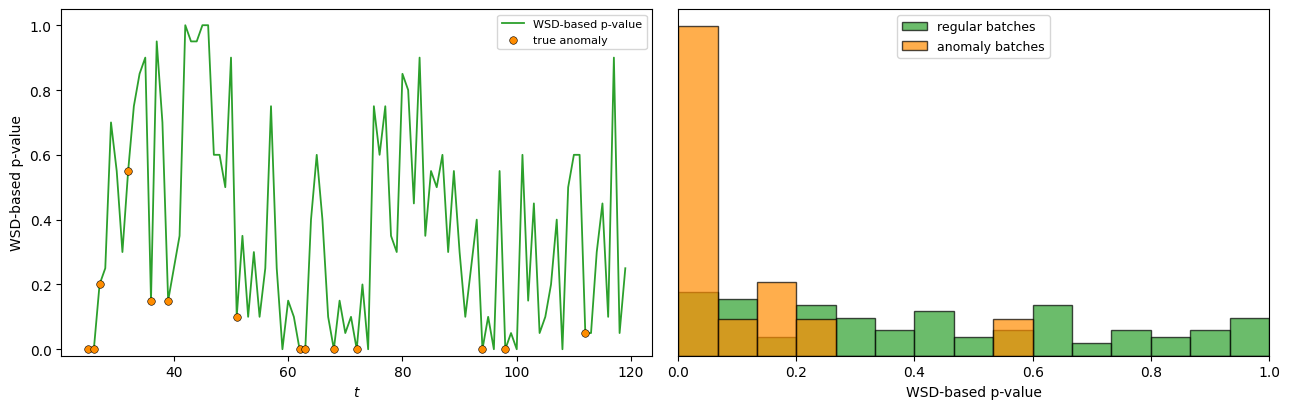

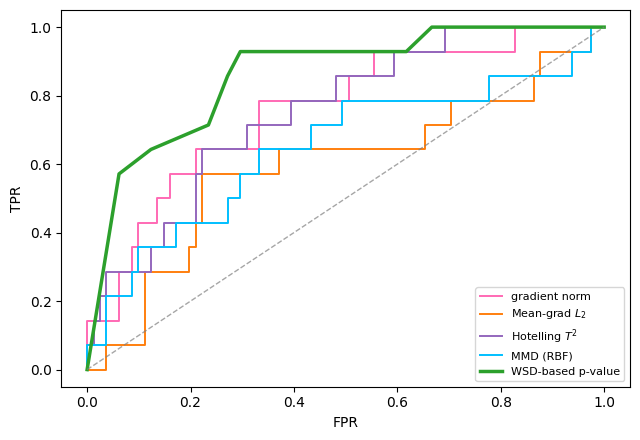

In [44]:
# ============================ Figures 3 & 4 (online regression) ============================
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

B, W, ANOM_JITTER, DRIFT_SIG = 60, 20, 0.6, 0.10

SEED_FIG = 0                      
out  = run_stream(seed=SEED_FIG, verbose=False)
R, anom, full = out["R"], out["anom"], out["full"]
mask = ~np.isnan(R)
lab  = anom.astype(int)
t    = np.arange(T)
print(f"evaluated rounds: {mask.sum()}   anomalies: {lab[mask].sum()}")
for name in ['Loss (norm)', 'Mean-grad L2', 'Hotelling T2', 'MMD (RBF)', 'R-stat']:
    print(f"  {name:<14} AUC = {roc_auc_score(lab[mask], full[name][mask]):.3f}")

# ---- Figure 3 
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.2))
axL.plot(t[mask], R[mask], '-', color='tab:green', lw=1.3, label='WSD-based p-value')
hit = mask & (lab == 1)
axL.scatter(t[hit], R[hit], c='darkorange', s=30, edgecolor='black', lw=0.4, zorder=5,
            label='true anomaly')
axL.set_xlabel('$t$'); axL.set_ylabel('WSD-based p-value')
axL.set_ylim(-0.02, 1.05); axL.legend(loc='upper right', fontsize=8)
bins = np.linspace(0, 1, 16)
axR.hist(R[mask & (lab == 0)], bins=bins, density=True, alpha=0.7,
         color='tab:green', edgecolor='black', lw=0.4, label='regular batches')
axR.hist(R[mask & (lab == 1)], bins=bins, density=True, alpha=0.7,
         color='darkorange', edgecolor='black', lw=0.4, label='anomaly batches')
axR.set_xlabel('WSD-based p-value'); axR.set_xlim(0, 1); axR.set_yticks([])
axR.legend(loc='upper center', fontsize=9)
fig.tight_layout(); plt.show()

# ---- Figure 4 
COL  = {'Loss (norm)':'hotpink','Mean-grad L2':'tab:orange','Hotelling T2':'tab:purple',
        'MMD (RBF)':'deepskyblue','R-stat':'tab:green'}
DISP = {'Loss (norm)':'gradient norm','Mean-grad L2':'Mean-grad $L_2$',
        'Hotelling T2':'Hotelling $T^2$','MMD (RBF)':'MMD (RBF)','R-stat':'WSD-based p-value'}
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for name in ['Loss (norm)','Mean-grad L2','Hotelling T2','MMD (RBF)','R-stat']:
    fpr, tpr, _ = roc_curve(lab[mask], full[name][mask])
    ax.plot(fpr, tpr, lw=2.5 if name == 'R-stat' else 1.4, color=COL[name], label=DISP[name])
ax.plot([0, 1], [0, 1], '--', color='gray', lw=1, alpha=0.7)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.legend(loc='lower right', fontsize=8)
fig.tight_layout(); plt.show()

## §5 Streaming-MNIST CNN — Tables 3, 11, 12
Drifting-MNIST stream, SmallCNN, per-sample logits-gradient signal at the frozen anchor; WSD vs Hotelling $T^2$, gradient-norm, Mean-grad $L^2$, MMD.  **Needs `torch`, `torchvision` (MNIST), and POT.**

### Setup — stream, CNN, detection pipeline, evaluators (run once before the tables)

In [23]:
import time, warnings, copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from sklearn.metrics import roc_auc_score, roc_curve
from joblib import Parallel, delayed
from collections import deque, Counter
import ot
from scipy.spatial.distance import pdist
from scipy.stats import kstest, chisquare

warnings.filterwarnings("ignore")
torch.set_num_threads(2)

EPS = 1e-12
SINKHORN_ITER = 200
SINKHORN_REG_FACTOR = 0.01
NUM_CLASSES = 10

# --- SWEET-SPOT CONFIG ---
CONFIG = dict(
    T=120, batch_size=60, feat_dim=64, K_inner=5,
    burn_in=15, window_size=15,
    anomaly_rate=0.15, flip_rate=0.10, lr=0.05,
    seed=0, drift_alpha=0.4, signal='logits_grad',
    use_anchor=True,
)

MULTI_SEEDS = [0, 1, 2, 3, 4]
CHI2_BINS = 10           # K for chi-square; expected ~ n/K = 9 per bin

print("Config:", CONFIG)
print(f"Seeds: {MULTI_SEEDS}")
print(f"Chi-square bins: {CHI2_BINS}")

Config: {'T': 120, 'batch_size': 60, 'feat_dim': 64, 'K_inner': 5, 'burn_in': 15, 'window_size': 15, 'anomaly_rate': 0.15, 'flip_rate': 0.1, 'lr': 0.05, 'seed': 0, 'drift_alpha': 0.4, 'signal': 'logits_grad', 'use_anchor': True}
Seeds: [0, 1, 2, 3, 4]
Chi-square bins: 10


In [24]:
# ---- alpha-test knobs (CNN) — identical values to the OSGD ablation notebook ----
CNN_N_SEEDS = 20
CNN_SEEDS   = list(range(CNN_N_SEEDS))
CNN_ALPHAS  = [0.02, 0.05, 0.10, 0.15, 0.20]
CNN_B_BASE  = 60      # paper batch_size
CNN_METHODS = ['R-stat', 'Hotelling T2', 'Loss (norm)', 'Mean-grad L2', 'MMD (RBF)']

# === The ONLY change vs the paper CNN configuration ===
# w_hat = mean(ref_depths <= z_t) is a RANK statistic against the W reference depths,
# resolved in steps of 1/W. Paper W=15 -> 1/15 ~ 0.067 (alpha=0.02 == alpha=0.05).
# W=50 -> resolution 1/50 = 0.02, so alpha=0.02 is a distinct decision level.
WINDOW_SIZE = 50
print("alpha-test knobs ready.  WINDOW_SIZE =", WINDOW_SIZE)

alpha-test knobs ready.  WINDOW_SIZE = 50


In [25]:
class DriftingMNIST:
    def __init__(self, T=200, batch_size=60, anomaly_rate=0.10,
                 flip_rate=0.50, drift_alpha=1.0, seed=0, root='./data'):
        self.T = T
        self.B = batch_size
        self.anomaly_rate = anomaly_rate
        self.flip_rate = flip_rate
        self.rng = np.random.RandomState(seed)
        self.last_active_mode = None

        ds = datasets.MNIST(root=root, train=True, download=True,
                            transform=transforms.ToTensor())
        self.X_all = ds.data.float().unsqueeze(1) / 255.0
        self.y_all = ds.targets.numpy().astype(np.int64)
        self.idx_by_digit = {d: np.where(self.y_all == d)[0]
                             for d in range(NUM_CLASSES)}

        r = np.random.RandomState(1000)
        self.p_start = r.dirichlet(np.ones(NUM_CLASSES) * drift_alpha)
        self.p_end   = r.dirichlet(np.ones(NUM_CLASSES) * drift_alpha)

    def class_ratio(self, t):
        a = t / max(self.T - 1, 1)
        return (1 - a) * self.p_start + a * self.p_end

    def __call__(self, t, force_clean=False):
        is_anomaly = (not force_clean) and (self.rng.rand() < self.anomaly_rate)
        p = self.class_ratio(t)
        chosen = self.rng.choice(NUM_CLASSES, size=self.B, p=p)
        Xs, ys = [], []
        for d in chosen:
            i = self.rng.choice(self.idx_by_digit[d])
            Xs.append(self.X_all[i])
            ys.append(int(d))
        X = torch.stack(Xs)
        y = torch.tensor(ys, dtype=torch.long)
        self.last_active_mode = None
        if force_clean:
            return X, y, False
        if is_anomaly:
            n_flip = int(self.B * self.flip_rate)
            idx = self.rng.choice(self.B, n_flip, replace=False)
            for i in idx:
                cur_d = int(y[i].item())
                others = [d for d in range(NUM_CLASSES) if d != cur_d]
                tgt_d = int(self.rng.choice(others))
                y[i] = tgt_d
            self.last_active_mode = 'label_flip'
        return X, y, is_anomaly

print("DriftingMNIST loaded.")

DriftingMNIST loaded.


In [26]:
class SmallCNN(nn.Module):
    def __init__(self, feat_dim=64, num_classes=NUM_CLASSES):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, feat_dim), nn.ReLU(),
        )
        self.classifier = nn.Linear(feat_dim, num_classes)
        self.feat_dim = feat_dim
        self.K = num_classes

    def forward(self, x):
        return self.classifier(self.backbone(x))


@torch.no_grad()
def per_sample_signal(model, X, y, signal='logits_grad'):
    if signal == 'logits_grad':
        logits = model(X)
        p = F.softmax(logits, dim=1)
        onehot = F.one_hot(y, num_classes=model.K).float()
        return (p - onehot).cpu().numpy()
    elif signal == 'feature':
        return model.backbone(X).cpu().numpy()
    raise ValueError(signal)


def batch_to_distribution(g):
    n, d = g.shape
    out = np.zeros((n, d, 2), dtype=np.float64)
    out[:, :, 0] = g
    out[:, 0, 1] = 1.0 / n
    return out

print("SmallCNN, per_sample_signal, batch_to_distribution loaded.")

SmallCNN, per_sample_signal, batch_to_distribution loaded.


In [27]:
def recompute_reference_depths(window, n_jobs=1):
    maxlen = window.maxlen
    W_cur = len(window)
    if W_cur == 0:
        return deque(maxlen=maxlen)
    if W_cur == 1:
        return deque([1.0], maxlen=maxlen)
    Xref = np.stack(list(window), axis=0)
    labels_ref = np.zeros(W_cur, dtype=int)
    return deque(compute_WSD_X(Xref, labels_ref, n_jobs=n_jobs).tolist(),
                 maxlen=maxlen)


def loo_depth_against_window(eta, window_list):
    if len(window_list) < 1:
        return 1.0
    Y = eta[None, ...]
    X = np.stack(window_list, axis=0)
    return float(compute_WSD_Y(Y, X, n_jobs=1)[0])


def freeze_anchor(model):
    anchor = copy.deepcopy(model).eval()
    for p in anchor.parameters():
        p.requires_grad = False
    return anchor


def run_one(cfg, return_grad_records=False):
    torch.manual_seed(cfg["seed"])
    np.random.seed(cfg["seed"])

    model = SmallCNN(feat_dim=cfg["feat_dim"], num_classes=NUM_CLASSES)
    total_horizon = cfg["T"] + cfg["burn_in"]
    use_anchor = cfg.get("use_anchor", True)
    signal = cfg.get("signal", "logits_grad")
    K_inner = cfg["K_inner"]
    lr = cfg["lr"]

    stream = DriftingMNIST(
        T=total_horizon, batch_size=cfg["batch_size"],
        anomaly_rate=cfg["anomaly_rate"], flip_rate=cfg["flip_rate"],
        drift_alpha=cfg.get("drift_alpha", 1.0), seed=cfg["seed"],
    )

    opt = torch.optim.SGD(model.parameters(), lr=lr)
    raw_buf = []
    for t in range(cfg["burn_in"]):
        X, y, _ = stream(t, force_clean=True)
        for _ in range(K_inner):
            opt.zero_grad()
            F.cross_entropy(model(X), y).backward()
            opt.step()
        raw_buf.append((X.detach().clone(), y.detach().clone()))

    detector_model = freeze_anchor(model) if use_anchor else model

    initial_etas = [
        batch_to_distribution(per_sample_signal(detector_model, X, y, signal=signal))
        for (X, y) in raw_buf[-cfg["window_size"]:]
    ]
    window = deque(initial_etas, maxlen=cfg["window_size"])
    ref_depths = recompute_reference_depths(window, n_jobs=1)

    Xte_idx = np.random.RandomState(999).choice(
        len(stream.y_all), min(2000, len(stream.y_all)), replace=False)
    Xte = stream.X_all[Xte_idx]
    yte = torch.tensor([int(d) for d in stream.y_all[Xte_idx]],
                       dtype=torch.long)

    rows, test_accs, times = [], [], []
    grad_records = [] if return_grad_records else None

    model.train()
    for step in range(cfg["T"]):
        stream_t = cfg["burn_in"] + step
        X, y, is_anom = stream(stream_t)

        g = per_sample_signal(detector_model, X, y, signal=signal)
        if return_grad_records:
            grad_records.append((g.copy(), int(is_anom)))
        eta_t = batch_to_distribution(g)

        if len(window) >= 2:
            tic = time.perf_counter()
            z_t = loo_depth_against_window(eta_t, list(window))
            times.append((time.perf_counter() - tic) * 1000.0)
            ref_arr = np.asarray(ref_depths, dtype=float)
            r_t = float(np.mean(ref_arr <= z_t))
        else:
            z_t = 1.0; r_t = 1.0
        rows.append((stream_t, z_t, r_t, is_anom))

        for _ in range(K_inner):
            opt.zero_grad()
            F.cross_entropy(model(X), y).backward()
            opt.step()

        window.append(eta_t)
        ref_depths = recompute_reference_depths(window, n_jobs=1)

        if (step + 1) % 30 == 0:
            model.eval()
            with torch.no_grad():
                acc = (model(Xte).argmax(1) == yte).float().mean().item()
            test_accs.append((step + 1, acc))
            model.train()

    rows = np.array(rows)
    out = {
        "t": rows[:, 0].astype(int),
        "depth": rows[:, 1].astype(float),
        "rstat": rows[:, 2].astype(float),
        "is_anomaly": rows[:, 3].astype(bool),
        "test_accs": test_accs,
        "ms_per_round": np.array(times),
    }
    if return_grad_records:
        out["grad_records"] = grad_records
    return out

print("run_one loaded.")

run_one loaded.


In [28]:
def compute_baseline_scores(grad_records, W):
    T_total = len(grad_records)
    gs = np.stack([rec[0] for rec in grad_records], axis=0)
    truth = np.array([rec[1] for rec in grad_records])

    loss_score = np.array([np.linalg.norm(g, axis=1).mean() for g in gs])
    meang = gs.mean(axis=1)
    mean_l2 = np.zeros(T_total)
    for t in range(T_total):
        if t < 2: continue
        lo = max(0, t - W)
        ref = meang[lo:t].mean(axis=0)
        mean_l2[t] = np.linalg.norm(meang[t] - ref)

    ht = np.zeros(T_total)
    for t in range(T_total):
        if t < W + 1: continue
        past = meang[t-W:t]
        mu = past.mean(axis=0)
        cov = np.cov(past.T) + 1e-3 * np.eye(meang.shape[1])
        diff = meang[t] - mu
        try:
            ht[t] = float(diff @ np.linalg.pinv(cov) @ diff)
        except Exception:
            ht[t] = 0.0

    def mmd2(X, Y, sigma):
        def k(A, B):
            d2 = np.sum(A**2,1)[:,None] + np.sum(B**2,1)[None,:] - 2*A@B.T
            return np.exp(-d2 / (2*sigma**2))
        return (k(X,X).sum()/len(X)**2 + k(Y,Y).sum()/len(Y)**2
                - 2*k(X,Y).sum()/(len(X)*len(Y)))

    mmd = np.zeros(T_total)
    for t in range(T_total):
        if t < W: continue
        Xt = gs[t]
        pool = np.concatenate([gs[k] for k in range(t-W, t)], axis=0)
        if len(pool) > 5*len(Xt):
            idx = np.random.RandomState(t).choice(len(pool), 5*len(Xt), replace=False)
            pool = pool[idx]
        sigma = max(np.median(pdist(np.vstack([Xt, pool])[:200])), 1e-3)
        mmd[t] = mmd2(Xt, pool, sigma)

    return ({'Loss (norm)': loss_score, 'Mean-grad L2': mean_l2,
             'Hotelling T2': ht, 'MMD (RBF)': mmd}, truth)


def assemble_full_scores(scores, depth, rstat):
    full = dict(scores)
    full['Bare WSD'] = -depth
    full['R-stat']   = -rstat
    return full


def compute_aucs(full, truth, mask):
    out = {}
    n_pos = int(truth[mask].sum()); n_neg = int((1-truth[mask]).sum())
    for name, s in full.items():
        out[name] = (roc_auc_score(truth[mask], s[mask])
                     if n_pos and n_neg else float('nan'))
    return out

print("Baselines loaded.")

Baselines loaded.


In [29]:
def _trailing_rank_pvalues(scores, anom, mask, W, larger_anomalous=True):
    """Calibrate a per-batch score into an empirical p-value by ranking it against a
    trailing window of the most recent W clean-batch scores (same as the online-regression
    notebook). larger_anomalous=True -> p = mean(ref >= score); else p = mean(ref <= score)."""
    p = np.full(len(scores), np.nan)
    ref = deque(maxlen=W)
    for t in range(len(scores)):
        if not mask[t]:
            continue
        s = scores[t]
        if len(ref) > 0:
            r = np.asarray(ref)
            p[t] = float(np.mean(r >= s)) if larger_anomalous else float(np.mean(r <= s))
        if not anom[t]:
            ref.append(s)
    return p

def eval_cnn_alpha_allmethods(batch_size, window_size, seeds=CNN_SEEDS, alphas=CNN_ALPHAS):
    """Run the UNCHANGED run_one with window_size overridden; score every detector under the
    common rule (flag if p-value < alpha). WSD uses its native rstat; the four baselines are
    calibrated to empirical p-values via _trailing_rank_pvalues. Returns (auc, atab) where
    atab[method][alpha] holds the per-seed FPR / TPR / precision lists."""
    auc  = {m: [] for m in CNN_METHODS}
    atab = {m: {a: {'FPR': [], 'TPR': [], 'precision': []} for a in alphas} for m in CNN_METHODS}
    for s in seeds:
        cfg = dict(CONFIG, seed=s, batch_size=batch_size, window_size=window_size)
        out = run_one(cfg, return_grad_records=True)
        Wc  = cfg['window_size']
        sc, truth = compute_baseline_scores(out['grad_records'], Wc)
        full = assemble_full_scores(sc, out['depth'], out['rstat'])
        mask = np.arange(len(truth)) >= Wc
        anom = out['is_anomaly']
        au = compute_aucs(full, truth, mask)
        for m in CNN_METHODS:
            auc[m].append(au[m])
        # per-batch p-value per detector
        pval = {'R-stat': np.asarray(out['rstat'], dtype=float)}          # native WSD empirical p-value
        for name in ['Hotelling T2', 'Loss (norm)', 'Mean-grad L2', 'MMD (RBF)']:
            pval[name] = _trailing_rank_pvalues(np.asarray(sc[name], dtype=float),
                                                anom.astype(bool), mask, Wc, larger_anomalous=True)
        # FPR / TPR / precision via the same alpha_table rule (flag if p-value < alpha)
        for m in CNN_METHODS:
            rows = alpha_table(pval[m], anom, alphas, mask=mask)
            for a in alphas:
                atab[m][a]['FPR'].append(rows[a]['FPR'])
                atab[m][a]['TPR'].append(rows[a]['TPR'])
                atab[m][a]['precision'].append(rows[a]['precision'])
    return auc, atab

print("all-method evaluator ready.")

all-method evaluator ready.


In [30]:
# ---- ablation knobs (CNN) ----
CNN_N_SEEDS    = 20
CNN_SEEDS      = list(range(CNN_N_SEEDS))
CNN_ALPHAS     = [0.02, 0.05, 0.10, 0.15, 0.20]
CNN_B_BASE     = 60      # paper batch_size
CNN_W_BASE     = 15      # paper window_size
CNN_BATCH_GRID  = [50, 80, 100, 120]
CNN_WINDOW_GRID = [16, 20, 26, 32, 40]
CNN_METHODS = ['R-stat', 'Hotelling T2', 'Loss (norm)', 'Mean-grad L2', 'MMD (RBF)']


def eval_cnn_config(batch_size, window_size, seeds=CNN_SEEDS, alphas=CNN_ALPHAS):
    """Run the UNCHANGED run_one with a CONFIG whose batch_size / window_size are
    changed; collect AUC (via compute_aucs) + the WSD alpha-table from rstat."""
    auc  = {name: [] for name in CNN_METHODS}
    atab = {a: {'FPR': [], 'TPR': [], 'precision': []} for a in alphas}
    for s in seeds:
        cfg = dict(CONFIG, seed=s, batch_size=batch_size, window_size=window_size)
        out = run_one(cfg, return_grad_records=True)
        Wc = cfg['window_size']
        sc, truth = compute_baseline_scores(out['grad_records'], Wc)
        full = assemble_full_scores(sc, out['depth'], out['rstat'])
        mask = np.arange(len(truth)) >= Wc
        au = compute_aucs(full, truth, mask)
        for name in CNN_METHODS:
            auc[name].append(au[name])
        rows = alpha_table(out['rstat'], out['is_anomaly'], alphas, mask=mask)
        for a in alphas:
            atab[a]['FPR'].append(rows[a]['FPR'])
            atab[a]['TPR'].append(rows[a]['TPR'])
            atab[a]['precision'].append(rows[a]['precision'])
    return auc, atab


print("CNN ablation helper ready.")


CNN ablation helper ready.


### Table 3 — default-config AUC

In [ ]:
# ============================== Table 3 ==============================
# Headline AUC at the §5 DEFAULT = base point of the Table 11 batch & window panels:
# m=60, W=15, flip_rate=0.10, anomaly_rate=0.15  (all CONFIG defaults; no mutation).
# W=50 is used ONLY in Table 12 / the flip panel (there the alpha-table needs 1/W <= alpha).
CNN_AUC3, _ = eval_cnn_config(CNN_B_BASE, CNN_W_BASE)        # (60, 15) at CONFIG defaults
order = ["R-stat", "Hotelling T2", "Loss (norm)", "Mean-grad L2", "MMD (RBF)"]
disp  = {"R-stat":"WSD-based p-value","Hotelling T2":"Hotelling T2","Loss (norm)":"Gradient norm",
         "Mean-grad L2":"Mean-grad L2","MMD (RBF)":"MMD (RBF)"}
print(f"Table 3:  streaming-MNIST ROC-AUC   "
      f"(m={CNN_B_BASE}, W={CNN_W_BASE}, anomaly_rate={CONFIG['anomaly_rate']}, 20 seeds)\n")
print(f"  {'Anomaly detector':<22}{'AUC':>16}")
for k in order:
    a = np.array(CNN_AUC3[k]); print(f"  {disp[k]:<22}{f'{a.mean():.3f} ± {a.std():.3f}':>16}")

Table 3:  streaming-MNIST ROC-AUC   (m=60, W=15, rate=0.15, 20 seeds)

  Anomaly detector                   AUC
  WSD-based p-value        0.927 ± 0.027
  Hotelling T2             0.752 ± 0.072
  Gradient norm            0.741 ± 0.061
  Mean-grad L2             0.683 ± 0.081
  MMD (RBF)                0.664 ± 0.072


### Table 11 — AUC sensitivity

In [32]:
# ============================== Table 11 =============================
# Streaming-MNIST AUC sensitivity (batch m & window W at W=15/m=60; label-flip rate at W=50). 20 seeds.
order = ["R-stat", "Mean-grad L2", "Hotelling T2", "Loss (norm)", "MMD (RBF)"]
hdr   = ["WSD-based", "Mean-grad L2", "Hotelling T2", "Grad-norm", "MMD"]
def _au(auc, k): a = np.array(auc[k]); return f"{a.mean():.3f} \u00b1 {a.std():.3f}"
def _line(label, auc): print(f"  {label:<8}" + "".join(f"{_au(auc, k):>18}" for k in order))
print("Table 11:  streaming-MNIST AUC sensitivity   (mean \u00b1 s.d., 20 seeds)\n")
print(f"  {'':<8}" + "".join(f"{h:>18}" for h in hdr))
print("Batch size m  (W=15)")
for B_val in CNN_BATCH_GRID:
    auc, _ = eval_cnn_config(B_val, CNN_W_BASE); _line(str(B_val), auc)
print("Window size W  (m=60)")
for W_val in CNN_WINDOW_GRID:
    auc, _ = eval_cnn_config(CNN_B_BASE, W_val); _line(str(W_val), auc)
print("Label-flip rate  (W=50)")
_old = CONFIG["flip_rate"]
try:
    for f_val in [0.05, 0.10, 0.15, 0.20]:
        CONFIG["flip_rate"] = f_val
        auc, _ = eval_cnn_alpha_allmethods(CNN_B_BASE, WINDOW_SIZE); _line(f"{f_val:.2f}", auc)
finally:
    CONFIG["flip_rate"] = _old

Table 11:  streaming-MNIST AUC sensitivity   (mean ± s.d., 20 seeds)

                   WSD-based      Mean-grad L2      Hotelling T2         Grad-norm               MMD
Batch size m  (W=15)
  50           0.919 ± 0.036     0.666 ± 0.059     0.722 ± 0.071     0.742 ± 0.067     0.625 ± 0.063
  80           0.941 ± 0.025     0.726 ± 0.048     0.782 ± 0.047     0.790 ± 0.057     0.703 ± 0.064
  100          0.953 ± 0.015     0.729 ± 0.068     0.771 ± 0.057     0.767 ± 0.081     0.732 ± 0.061
  120          0.951 ± 0.023     0.740 ± 0.052     0.790 ± 0.053     0.788 ± 0.045     0.753 ± 0.046
Window size W  (m=60)
  16           0.928 ± 0.028     0.682 ± 0.080     0.749 ± 0.071     0.739 ± 0.061     0.667 ± 0.075
  20           0.929 ± 0.026     0.683 ± 0.081     0.756 ± 0.072     0.742 ± 0.061     0.667 ± 0.082
  26           0.931 ± 0.028     0.679 ± 0.082     0.747 ± 0.072     0.747 ± 0.055     0.674 ± 0.088
  32           0.928 ± 0.036     0.671 ± 0.090     0.750 ± 0.081     0.755 ± 0.

### Table 12 — FPR / FNR vs $\alpha$

In [47]:
# ============================== Table 12 =============================
# Streaming-MNIST FPR / FNR at alpha in {0.02,0.05,0.10,0.20}, all five methods.
_, CNN_ATAB12 = eval_cnn_alpha_allmethods(CNN_B_BASE, WINDOW_SIZE)   # (60, 50)
order = ["R-stat", "Hotelling T2", "Mean-grad L2", "Loss (norm)", "MMD (RBF)"]
disp  = {"R-stat":"WSD-based","Hotelling T2":"Hotelling T2","Mean-grad L2":"Mean-grad L2","Loss (norm)":"Grad-norm","MMD (RBF)":"MMD"}
T12_ALPHAS = [0.02, 0.05, 0.10, 0.20]
print("Table 12:  streaming-MNIST FPR / FNR   (mean \u00b1 s.d., 20 seeds)\n")
print(f"  {'Method':<14}" + "".join(f"{'a='+str(a)+' FPR':>16}{'FNR':>16}" for a in T12_ALPHAS))
for m in order:
    row = f"  {disp[m]:<14}"
    for a in T12_ALPHAS:
        f = np.array(CNN_ATAB12[m][a]["FPR"]); t = np.array(CNN_ATAB12[m][a]["TPR"]); n = 1.0 - t
        row += f"{f'{f.mean():.3f}\u00b1{f.std():.3f}':>16}{f'{n.mean():.3f}\u00b1{n.std():.3f}':>16}"
    print(row)

Table 12:  streaming-MNIST FPR / FNR   (mean ± s.d., 20 seeds)

  Method              a=0.02 FPR             FNR      a=0.05 FPR             FNR       a=0.1 FPR             FNR       a=0.2 FPR             FNR
  WSD-based          0.018±0.022     0.780±0.118     0.050±0.032     0.524±0.153     0.091±0.037     0.320±0.145     0.228±0.075     0.101±0.105
  Hotelling T2       0.072±0.021     0.820±0.125     0.102±0.030     0.742±0.166     0.147±0.038     0.636±0.176     0.222±0.034     0.450±0.194
  Mean-grad L2       0.076±0.030     0.868±0.089     0.103±0.040     0.833±0.107     0.147±0.053     0.770±0.137     0.247±0.058     0.591±0.189
  Grad-norm          0.131±0.031     0.506±0.146     0.210±0.040     0.348±0.150     0.283±0.048     0.224±0.119     0.425±0.057     0.119±0.101
  MMD                0.065±0.025     0.827±0.113     0.085±0.023     0.787±0.135     0.128±0.033     0.738±0.151     0.189±0.042     0.573±0.151


total anomalies: 18   (within ROC-evaluated region: 16)
  Loss (norm)    AUC = 0.736
  Mean-grad L2   AUC = 0.697
  Hotelling T2   AUC = 0.733
  MMD (RBF)      AUC = 0.625
  R-stat         AUC = 0.939


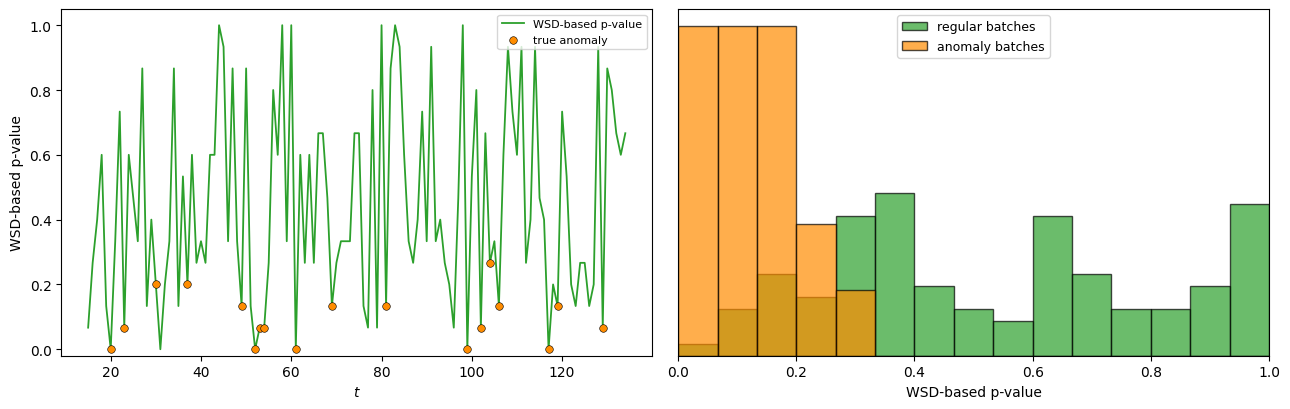

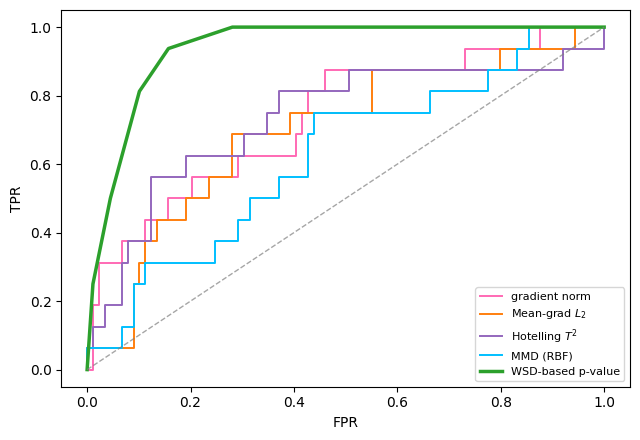

In [49]:
# ============== Figures 5 & 6 (streaming MNIST) — auto-pick a seed with exactly 18 anomalies ==============
# Reuses run_one() + the section-5 setup already defined above. The anomaly pattern is a per-batch
# Bernoulli(anomaly_rate) draw, so the count varies by seed (mean = rate*T = 18). PART 1 replays ONLY the
# DriftingMNIST sampling (no CNN training -> fast) to find a seed yielding exactly 18 anomalies, matching
# the paper's section-5 count. PART 2 runs that single stream (~1 min) and draws the figures.
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# ---------- PART 1: find a seed with exactly 18 anomalies ----------
# Only self.rng (seeded by `seed`) drives the anomaly pattern; class proportions come from a fixed
# RandomState(1000) and are seed-independent. We replicate run_one's EXACT call order on the same
# horizon T + burn_in: burn_in force-clean calls, then T monitored calls.
TARGET_ANOM = 18
_horizon = CONFIG['T'] + CONFIG['burn_in']
_probe = DriftingMNIST(T=_horizon, batch_size=CONFIG['batch_size'],
                       anomaly_rate=CONFIG['anomaly_rate'], flip_rate=CONFIG['flip_rate'],
                       drift_alpha=CONFIG['drift_alpha'], seed=0)

def _n_anom(seed):
    _probe.rng = np.random.RandomState(seed)          # reset to run_one's per-seed rng state
    for t in range(CONFIG['burn_in']):
        _probe(t, force_clean=True)                   # burn-in: force-clean (matches run_one)
    return sum(int(_probe(CONFIG['burn_in'] + k)[2]) for k in range(CONFIG['T']))

SEED_FIG = next((s for s in range(200) if _n_anom(s) == TARGET_ANOM), 0)
#print(f"using SEED_FIG = {SEED_FIG}  (exactly {TARGET_ANOM} anomalies)")

# ---------- PART 2: one stream + figures ----------
cfg = dict(CONFIG, seed=SEED_FIG)                      # section-5 default: m=60, W=15, flip 0.10, rate 0.15
out = run_one(cfg, return_grad_records=True)

tt    = out['t']                                       # stream_t (burn_in .. burn_in+T-1, i.e. 15..134)
rstat = out['rstat']                                   # WSD-based p-value w_hat (small = anomalous)
lab   = out['is_anomaly'].astype(int)
Wc    = cfg['window_size']

# baselines roll over grad_records and need W past batches -> first Wc rounds invalid; mask for the ROC
sc, truth = compute_baseline_scores(out['grad_records'], Wc)
full = assemble_full_scores(sc, out['depth'], out['rstat'])   # full['R-stat'] = -rstat (ROC orientation)
mask = np.arange(len(truth)) >= Wc

aucs = compute_aucs(full, truth, mask)
print(f"total anomalies: {lab.sum()}   (within ROC-evaluated region: {lab[mask].sum()})")
for name in ['Loss (norm)', 'Mean-grad L2', 'Hotelling T2', 'MMD (RBF)', 'R-stat']:
    print(f"  {name:<14} AUC = {aucs[name]:.3f}")

# ---- Figure 5 (p-value trajectory + histogram; all rounds, every anomaly marked) ----
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.2))
axL.plot(tt, rstat, '-', color='tab:green', lw=1.3, label='WSD-based p-value')
hit = lab == 1
axL.scatter(tt[hit], rstat[hit], c='darkorange', s=30, edgecolor='black', lw=0.4, zorder=5,
            label='true anomaly')
axL.set_xlabel('$t$'); axL.set_ylabel('WSD-based p-value')
axL.set_ylim(-0.02, 1.05); axL.legend(loc='upper right', fontsize=8)
bins = np.linspace(0, 1, 16)
axR.hist(rstat[lab == 0], bins=bins, density=True, alpha=0.7,
         color='tab:green', edgecolor='black', lw=0.4, label='regular batches')
axR.hist(rstat[lab == 1], bins=bins, density=True, alpha=0.7,
         color='darkorange', edgecolor='black', lw=0.4, label='anomaly batches')
axR.set_xlabel('WSD-based p-value'); axR.set_xlim(0, 1); axR.set_yticks([])
axR.legend(loc='upper center', fontsize=9)
fig.tight_layout(); plt.show()

# ---- Figure 6 (ROC of five methods; baseline-validity mask) ----
COL  = {'Loss (norm)':'hotpink','Mean-grad L2':'tab:orange','Hotelling T2':'tab:purple',
        'MMD (RBF)':'deepskyblue','R-stat':'tab:green'}
DISP = {'Loss (norm)':'gradient norm','Mean-grad L2':'Mean-grad $L_2$',
        'Hotelling T2':'Hotelling $T^2$','MMD (RBF)':'MMD (RBF)','R-stat':'WSD-based p-value'}
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for name in ['Loss (norm)','Mean-grad L2','Hotelling T2','MMD (RBF)','R-stat']:
    fpr, tpr, _ = roc_curve(truth[mask], full[name][mask])
    ax.plot(fpr, tpr, lw=2.5 if name == 'R-stat' else 1.4, color=COL[name], label=DISP[name])
ax.plot([0, 1], [0, 1], '--', color='gray', lw=1, alpha=0.7)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.legend(loc='lower right', fontsize=8)
fig.tight_layout(); plt.show()